


# UCI

### Imports

In [ ]:
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
import seaborn as sns
import sklearn
from sklearn.neighbors import KNeighborsClassifier
from sklearn.naive_bayes import GaussianNB
from sklearn.metrics import accuracy_score, f1_score, roc_auc_score, ConfusionMatrixDisplay, classification_report
from sklearn.ensemble import RandomForestClassifier, GradientBoostingClassifier
from sklearn.model_selection import GridSearchCV, cross_val_score
from tensorflow.keras.models import Sequential
from tensorflow.keras.layers import Conv1D, MaxPooling1D, Flatten, Dense, Dropout
from tensorflow.keras.optimizers import SGD
from tensorflow.keras.models import Model
from tensorflow.keras.layers import Input, Conv1D
from tensorflow.keras.models import Model
from tensorflow.keras.layers import LSTM
from tensorflow.keras.callbacks import EarlyStopping
import time

## Get Dataset Folder

In [ ]:
# Download dataset
!wget https://archive.ics.uci.edu/static/public/240/human+activity+recognition+using+smartphones.zip

--2026-05-10 15:28:32--  https://archive.ics.uci.edu/static/public/240/human+activity+recognition+using+smartphones.zip
Resolving archive.ics.uci.edu (archive.ics.uci.edu)... 128.195.10.252
Connecting to archive.ics.uci.edu (archive.ics.uci.edu)|128.195.10.252|:443... connected.
HTTP request sent, awaiting response... 200 OK
Length: unspecified
Saving to: ‘human+activity+recognition+using+smartphones.zip’

human+activity+reco     [     <=>            ]  58.18M  67.9MB/s    in 0.9s    

2026-05-10 15:28:33 (67.9 MB/s) - ‘human+activity+recognition+using+smartphones.zip’ saved [61005872]



In [ ]:
!unzip -q human+activity+recognition+using+smartphones.zip

In [ ]:
!unzip UCI\ HAR\ Dataset.zip

In [ ]:
#rename
!mv UCI\ HAR\ Dataset Dataset

# Phase 1

## Data Preprocessing

In [ ]:
# get feature names from the file features.txt
features = list()
with open('/content/Dataset/features.txt') as f:
    features = [line.split()[1] for line in f.readlines()]

print('No of Features: {}'.format(len(features)))

No of Features: 561


### Duplicate features:

In [ ]:
seen = set()
uniq_features = []
for idx, x in enumerate(features):
    if x not in seen:
        uniq_features.append(x)
        seen.add(x)
    elif x + 'n' not in seen:
        uniq_features.append(x + 'n')
        seen.add(x + 'n')
    else:
        uniq_features.append(x + 'nn')
        seen.add(x + 'nn')
len(uniq_features)

561

### Obtain the train data

In [ ]:
import pandas as pd

# Load features
X_train = pd.read_csv(
    "/content/Dataset/train/X_train.txt",
    sep="\s+",
    header=None,
    names=uniq_features,
    engine='python'
)

# Load subject
subject_train = pd.read_csv(
   "/content/Dataset/train/subject_train.txt",
    header=None,
    names=['subject']
)

# Load activity labels
y_train = pd.read_csv(
    "/content/Dataset/train/y_train.txt",
    header=None,
    names=['Activity']
)

# Concatenate all together
train = pd.concat([X_train, subject_train, y_train], axis=1)
train['Activity_name'] = train['Activity'].map({
    1: 'WALKING',
    2: 'WALKING_UPSTAIRS',
    3: 'WALKING_DOWNSTAIRS',
    4: 'SITTING',
    5: 'STANDING',
    6: 'LAYING'
})

print(train.shape)
train.head()

<>:6: SyntaxWarning: invalid escape sequence '\s'
<>:6: SyntaxWarning: invalid escape sequence '\s'
/tmp/ipykernel_6479/1485743234.py:6: SyntaxWarning: invalid escape sequence '\s'
  sep="\s+",


(7352, 564)


,tBodyAcc-mean()-X,tBodyAcc-mean()-Y,tBodyAcc-mean()-Z,tBodyAcc-std()-X,tBodyAcc-std()-Y,tBodyAcc-std()-Z,tBodyAcc-mad()-X,tBodyAcc-mad()-Y,tBodyAcc-mad()-Z,tBodyAcc-max()-X,...,"angle(tBodyAccMean,gravity)","angle(tBodyAccJerkMean),gravityMean)","angle(tBodyGyroMean,gravityMean)","angle(tBodyGyroJerkMean,gravityMean)","angle(X,gravityMean)","angle(Y,gravityMean)","angle(Z,gravityMean)",subject,Activity,Activity_name
0,0.288585,-0.020294,-0.132905,-0.995279,-0.983111,-0.913526,-0.995112,-0.983185,-0.923527,-0.934724,...,-0.112754,0.030400,-0.464761,-0.018446,-0.841247,0.179941,-0.058627,1,5,STANDING
1,0.278419,-0.016411,-0.123520,-0.998245,-0.975300,-0.960322,-0.998807,-0.974914,-0.957686,-0.943068,...,0.053477,-0.007435,-0.732626,0.703511,-0.844788,0.180289,-0.054317,1,5,STANDING
2,0.279653,-0.019467,-0.113462,-0.995380,-0.967187,-0.978944,-0.996520,-0.963668,-0.977469,-0.938692,...,-0.118559,0.177899,0.100699,0.808529,-0.848933,0.180637,-0.049118,1,5,STANDING
3,0.279174,-0.026201,-0.123283,-0.996091,-0.983403,-0.990675,-0.997099,-0.982750,-0.989302,-0.938692,...,-0.036788,-0.012892,0.640011,-0.485366,-0.848649,0.181935,-0.047663,1,5,STANDING
4,0.276629,-0.016570,-0.115362,-0.998139,-0.980817,-0.990482,-0.998321,-0.979672,-0.990441,-0.942469,...,0.123320,0.122542,0.693578,-0.615971,-0.847865,0.185151,-0.043892,1,5,STANDING


In [ ]:
y_train.sample()

,Activity
4515,2


In [ ]:
train.shape

(7352, 564)

### Obtain the test data

In [ ]:
import pandas as pd

# Load features
X_test = pd.read_csv(
   "/content/Dataset/test/X_test.txt",
    sep="\s+",
    header=None,
    names=uniq_features,
    engine='python'
)

# Load subject
subject_test = pd.read_csv(
    "/content/Dataset/test/subject_test.txt",
    header=None,
    names=['subject']
)

# Load activity labels
y_test = pd.read_csv(
    "/content/Dataset/test/y_test.txt",
    header=None,
    names=['Activity']
)

# Concatenate all together
test = pd.concat([X_test, subject_test, y_test], axis=1)

test['Activity_name'] = test['Activity'].map({
    1: 'WALKING',
    2: 'WALKING_UPSTAIRS',
    3: 'WALKING_DOWNSTAIRS',
    4: 'SITTING',
    5: 'STANDING',
    6: 'LAYING'
})
print(test.shape)
test.head()

<>:6: SyntaxWarning: invalid escape sequence '\s'
<>:6: SyntaxWarning: invalid escape sequence '\s'
/tmp/ipykernel_6479/1988745919.py:6: SyntaxWarning: invalid escape sequence '\s'
  sep="\s+",


(2947, 564)


,tBodyAcc-mean()-X,tBodyAcc-mean()-Y,tBodyAcc-mean()-Z,tBodyAcc-std()-X,tBodyAcc-std()-Y,tBodyAcc-std()-Z,tBodyAcc-mad()-X,tBodyAcc-mad()-Y,tBodyAcc-mad()-Z,tBodyAcc-max()-X,...,"angle(tBodyAccMean,gravity)","angle(tBodyAccJerkMean),gravityMean)","angle(tBodyGyroMean,gravityMean)","angle(tBodyGyroJerkMean,gravityMean)","angle(X,gravityMean)","angle(Y,gravityMean)","angle(Z,gravityMean)",subject,Activity,Activity_name
0,0.257178,-0.023285,-0.014654,-0.938404,-0.920091,-0.667683,-0.952501,-0.925249,-0.674302,-0.894088,...,0.006462,0.162920,-0.825886,0.271151,-0.720009,0.276801,-0.057978,2,5,STANDING
1,0.286027,-0.013163,-0.119083,-0.975415,-0.967458,-0.944958,-0.986799,-0.968401,-0.945823,-0.894088,...,-0.083495,0.017500,-0.434375,0.920593,-0.698091,0.281343,-0.083898,2,5,STANDING
2,0.275485,-0.026050,-0.118152,-0.993819,-0.969926,-0.962748,-0.994403,-0.970735,-0.963483,-0.939260,...,-0.034956,0.202302,0.064103,0.145068,-0.702771,0.280083,-0.079346,2,5,STANDING
3,0.270298,-0.032614,-0.117520,-0.994743,-0.973268,-0.967091,-0.995274,-0.974471,-0.968897,-0.938610,...,-0.017067,0.154438,0.340134,0.296407,-0.698954,0.284114,-0.077108,2,5,STANDING
4,0.274833,-0.027848,-0.129527,-0.993852,-0.967445,-0.978295,-0.994111,-0.965953,-0.977346,-0.938610,...,-0.002223,-0.040046,0.736715,-0.118545,-0.692245,0.290722,-0.073857,2,5,STANDING


In [ ]:
test.shape

(2947, 564)

### 1. Check for Duplicates

In [ ]:
#check for duplicates in the train and test datasets
print("Number of duplicate rows in train dataset: ", train.duplicated().sum())
print("Number of duplicate rows in test dataset: ", test.duplicated().sum())

Number of duplicate rows in train dataset:  0
Number of duplicate rows in test dataset:  0


### 2. Checking for NaN/null values

In [ ]:
print("is there any null value in the train dataset? ", train.isnull().values.any())
print("is there any null value in the test dataset? ", test.isnull().values.any())


is there any null value in the train dataset?  False
is there any null value in the test dataset?  False


### 3. Changing feature names

In [ ]:
columns = train.columns

# Removing '()' from column names
columns = columns.str.replace('[()]','')
columns = columns.str.replace('[-]', '')
columns = columns.str.replace('[,]','')

train.columns = columns
test.columns = columns

test.columns

Index(['tBodyAcc-mean()-X', 'tBodyAcc-mean()-Y', 'tBodyAcc-mean()-Z',
       'tBodyAcc-std()-X', 'tBodyAcc-std()-Y', 'tBodyAcc-std()-Z',
       'tBodyAcc-mad()-X', 'tBodyAcc-mad()-Y', 'tBodyAcc-mad()-Z',
       'tBodyAcc-max()-X',
       ...
       'angle(tBodyAccMean,gravity)', 'angle(tBodyAccJerkMean),gravityMean)',
       'angle(tBodyGyroMean,gravityMean)',
       'angle(tBodyGyroJerkMean,gravityMean)', 'angle(X,gravityMean)',
       'angle(Y,gravityMean)', 'angle(Z,gravityMean)', 'subject', 'Activity',
       'Activity_name'],
      dtype='object', length=564)

### 5. Save this dataframe in a csv files

In [ ]:
train.to_csv('train.csv', index=False)
test.to_csv('test.csv', index=False)

## EDA

In [ ]:
import seaborn as sns
import matplotlib.pyplot as plt
import pandas as pd

In [ ]:
df = pd.read_csv('train.csv')

In [ ]:
df.shape

(7352, 564)

In [ ]:
print(list(df.columns))

['tBodyAcc-mean()-X', 'tBodyAcc-mean()-Y', 'tBodyAcc-mean()-Z', 'tBodyAcc-std()-X', 'tBodyAcc-std()-Y', 'tBodyAcc-std()-Z', 'tBodyAcc-mad()-X', 'tBodyAcc-mad()-Y', 'tBodyAcc-mad()-Z', 'tBodyAcc-max()-X', 'tBodyAcc-max()-Y', 'tBodyAcc-max()-Z', 'tBodyAcc-min()-X', 'tBodyAcc-min()-Y', 'tBodyAcc-min()-Z', 'tBodyAcc-sma()', 'tBodyAcc-energy()-X', 'tBodyAcc-energy()-Y', 'tBodyAcc-energy()-Z', 'tBodyAcc-iqr()-X', 'tBodyAcc-iqr()-Y', 'tBodyAcc-iqr()-Z', 'tBodyAcc-entropy()-X', 'tBodyAcc-entropy()-Y', 'tBodyAcc-entropy()-Z', 'tBodyAcc-arCoeff()-X,1', 'tBodyAcc-arCoeff()-X,2', 'tBodyAcc-arCoeff()-X,3', 'tBodyAcc-arCoeff()-X,4', 'tBodyAcc-arCoeff()-Y,1', 'tBodyAcc-arCoeff()-Y,2', 'tBodyAcc-arCoeff()-Y,3', 'tBodyAcc-arCoeff()-Y,4', 'tBodyAcc-arCoeff()-Z,1', 'tBodyAcc-arCoeff()-Z,2', 'tBodyAcc-arCoeff()-Z,3', 'tBodyAcc-arCoeff()-Z,4', 'tBodyAcc-correlation()-X,Y', 'tBodyAcc-correlation()-X,Z', 'tBodyAcc-correlation()-Y,Z', 'tGravityAcc-mean()-X', 'tGravityAcc-mean()-Y', 'tGravityAcc-mean()-Z', 'tG

/tmp/ipykernel_549/2019651120.py:2: FutureWarning: 

Passing `palette` without assigning `hue` is deprecated and will be removed in v0.14.0. Assign the `x` variable to `hue` and set `legend=False` for the same effect.

  sns.countplot(x='Activity_name', data=df, palette='Set2')


<Axes: xlabel='Activity_name', ylabel='count'>

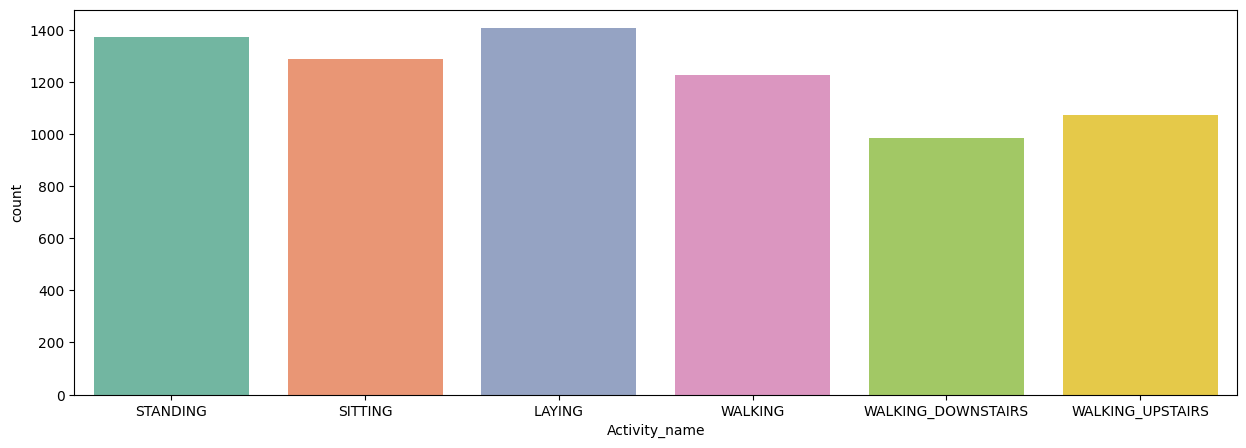

In [ ]:
plt.figure(figsize=(15,5))
sns.countplot(x='Activity_name', data=df, palette='Set2')

/tmp/ipykernel_549/1728281225.py:2: FutureWarning: 

Passing `palette` without assigning `hue` is deprecated and will be removed in v0.14.0. Assign the `x` variable to `hue` and set `legend=False` for the same effect.

  sns.boxplot(x='Activity_name', y='tBodyAccMag-mean()', data=df, palette='Set3')


<Axes: xlabel='Activity_name', ylabel='tBodyAccMag-mean()'>

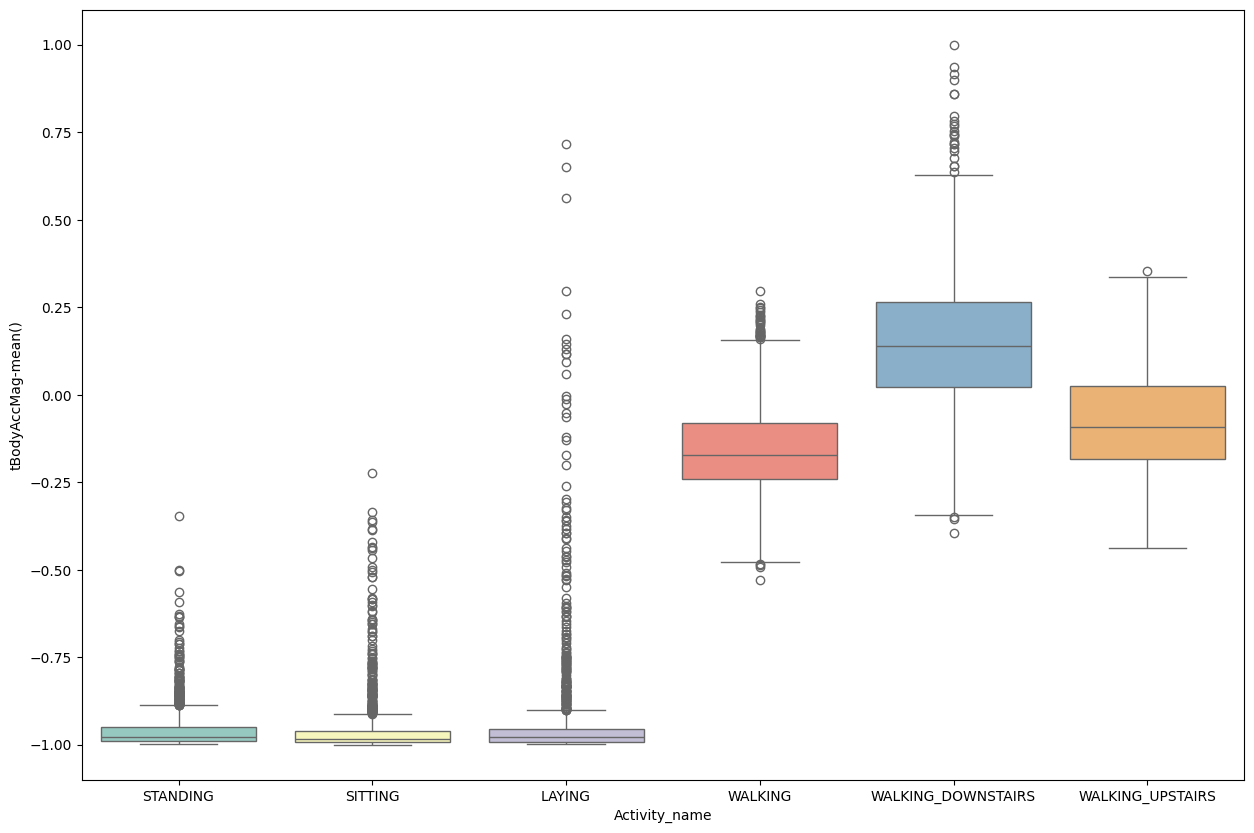

In [ ]:
plt.figure(figsize=(15,10))
sns.boxplot(x='Activity_name', y='tBodyAccMag-mean()', data=df, palette='Set3')

/tmp/ipykernel_549/891466962.py:2: FutureWarning: 

Passing `palette` without assigning `hue` is deprecated and will be removed in v0.14.0. Assign the `x` variable to `hue` and set `legend=False` for the same effect.

  sns.boxplot(x='Activity_name', y='tBodyGyroMag-mean()', data=df, palette='Set3')


<Axes: xlabel='Activity_name', ylabel='tBodyGyroMag-mean()'>

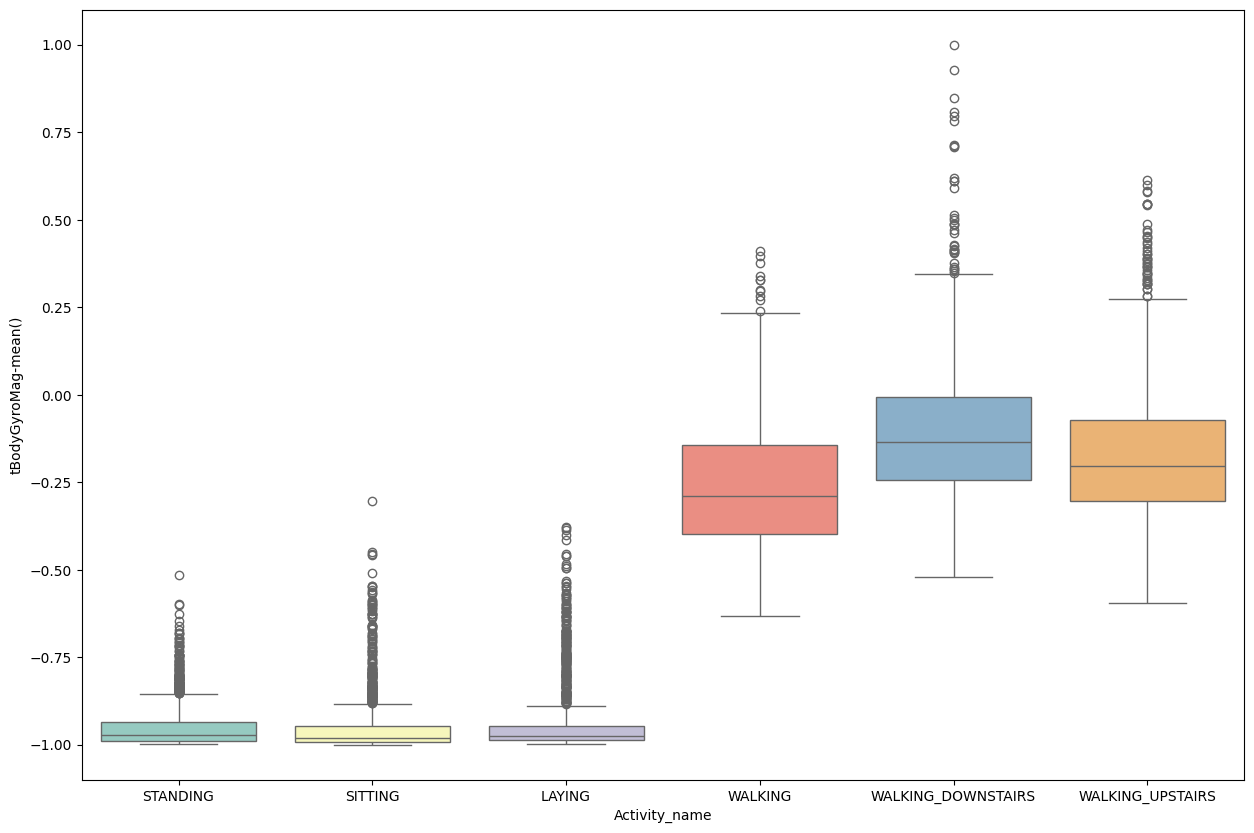

In [ ]:
plt.figure(figsize=(15,10))
sns.boxplot(x='Activity_name', y='tBodyGyroMag-mean()', data=df, palette='Set3')

<Axes: xlabel='tBodyGyroMag-mean()'>

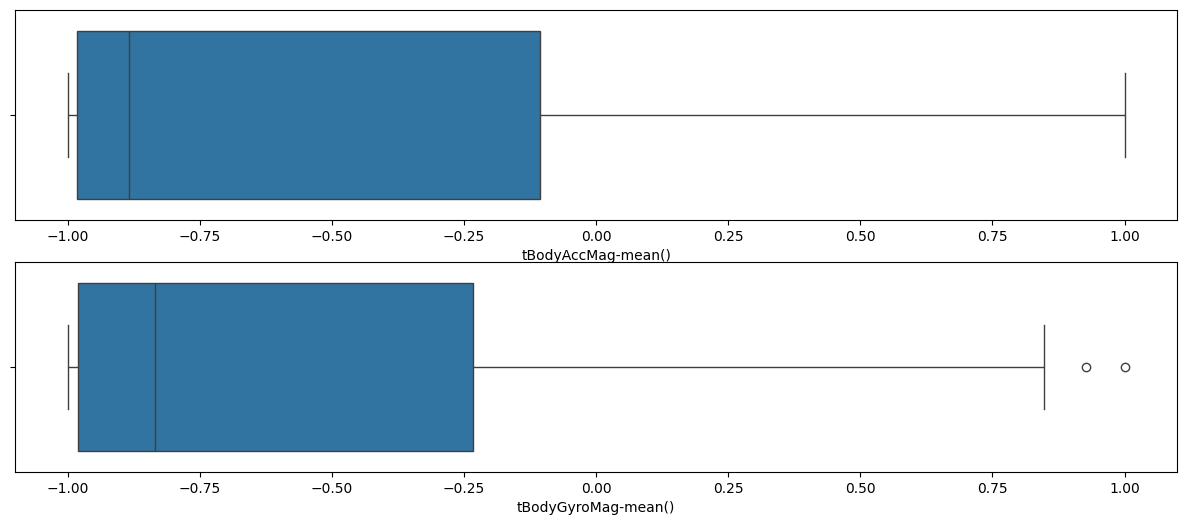

In [ ]:
fig, axes = plt.subplots(2, 1, figsize=(15,6))
sns.boxplot(x='tBodyAccMag-mean()', data=df, ax=axes[0])
sns.boxplot(x='tBodyGyroMag-mean()', data=df, ax=axes[1])

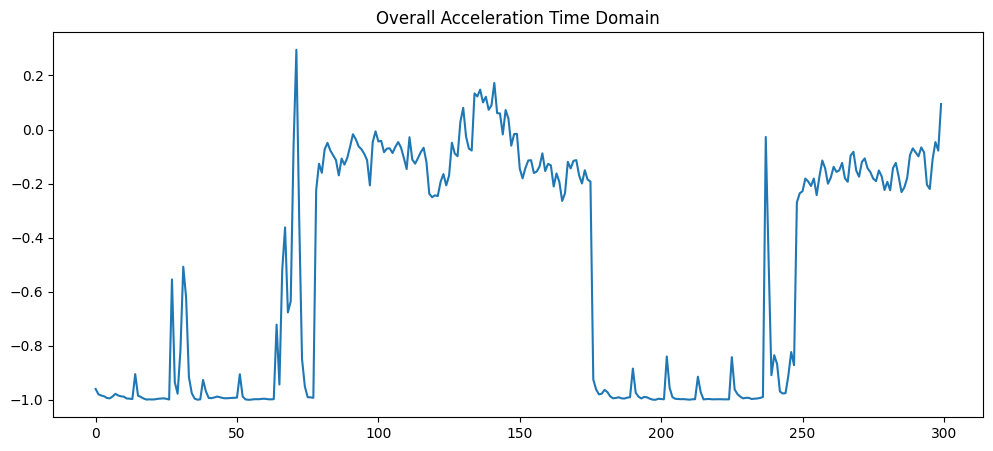

In [ ]:
# Plot overall acceleration over time
plt.figure(figsize=(12, 5))
plt.plot(df['tBodyAccMag-mean()'][:300], label='tBodyAccMag-mean()')
plt.title('Overall Acceleration Time Domain')
plt.show()

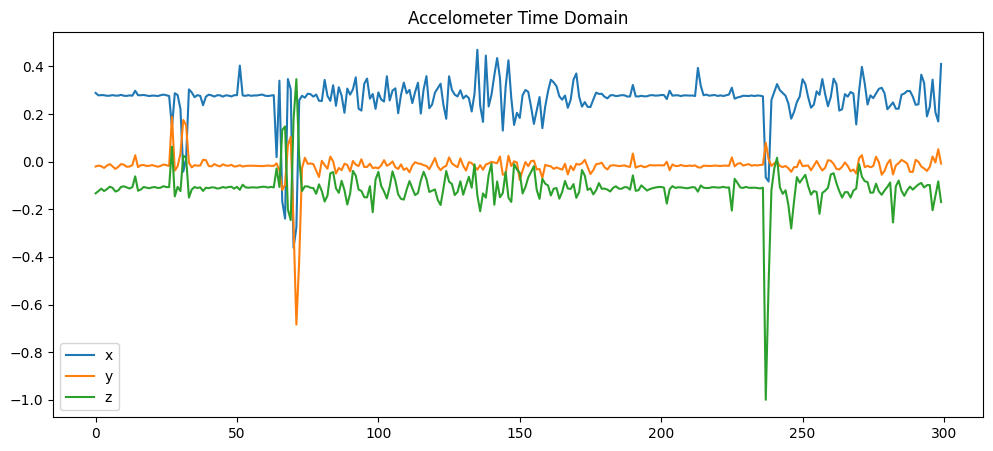

In [ ]:
# Plot accelometer signals over time
plt.figure(figsize=(12, 5))
plt.plot(df['tBodyAcc-mean()-X'][:300], label='tBodyAcc-mean()-X')
plt.plot(df['tBodyAcc-mean()-Y'][:300], label='tBodyAcc-mean()-Y')
plt.plot(df['tBodyAcc-mean()-Z'][:300], label='tBodyAcc-mean()-Z')
plt.legend(['x', 'y', 'z'])
plt.title('Accelometer Time Domain')
plt.show()

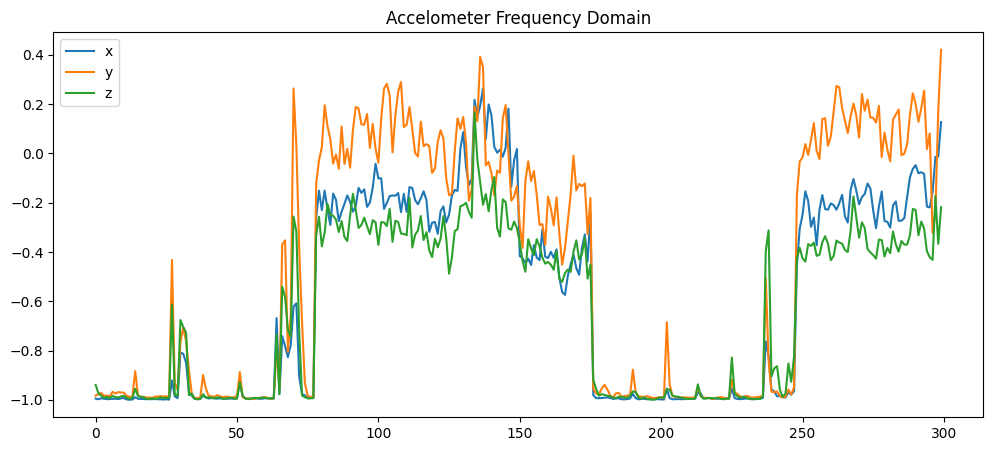

In [ ]:
# Plot accelometer signals in the frequency domain
plt.figure(figsize=(12, 5))
plt.plot(df['fBodyAcc-mean()-X'][:300], label='fBodyAcc-mean()-X')
plt.plot(df['fBodyAcc-mean()-Y'][:300], label='fBodyAcc-mean()-Y')
plt.plot(df['fBodyAcc-mean()-Z'][:300], label='fBodyAcc-mean()-Z')
plt.legend(['x', 'y', 'z'])
plt.title('Accelometer Frequency Domain')
plt.show()

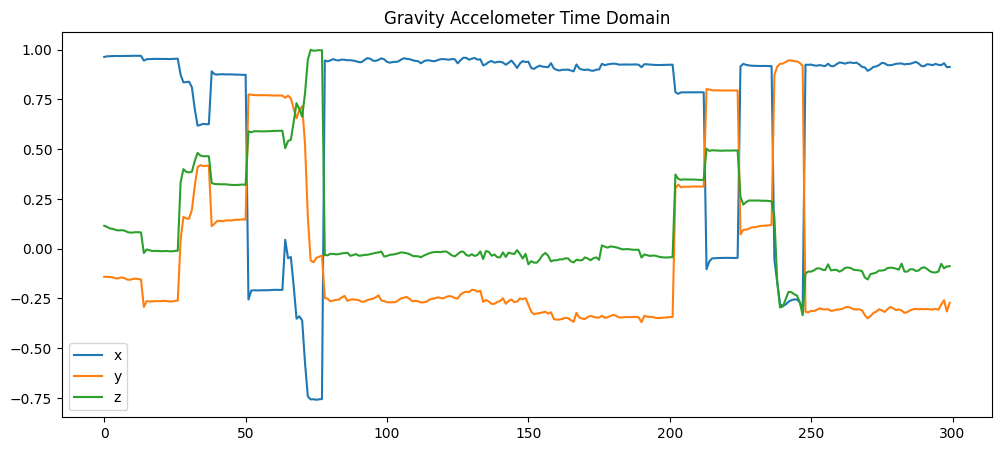

In [ ]:
# Plot gravity accelometer signals over time
plt.figure(figsize=(12, 5))
plt.plot(df['tGravityAcc-mean()-X'][:300], label='tGravityAcc-mean()-X')
plt.plot(df['tGravityAcc-mean()-Y'][:300], label='tGravityAcc-mean()-Y')
plt.plot(df['tGravityAcc-mean()-Z'][:300], label='tGravityAcc-mean()-Z')
plt.legend(['x', 'y', 'z'])
plt.title('Gravity Accelometer Time Domain')
plt.show()

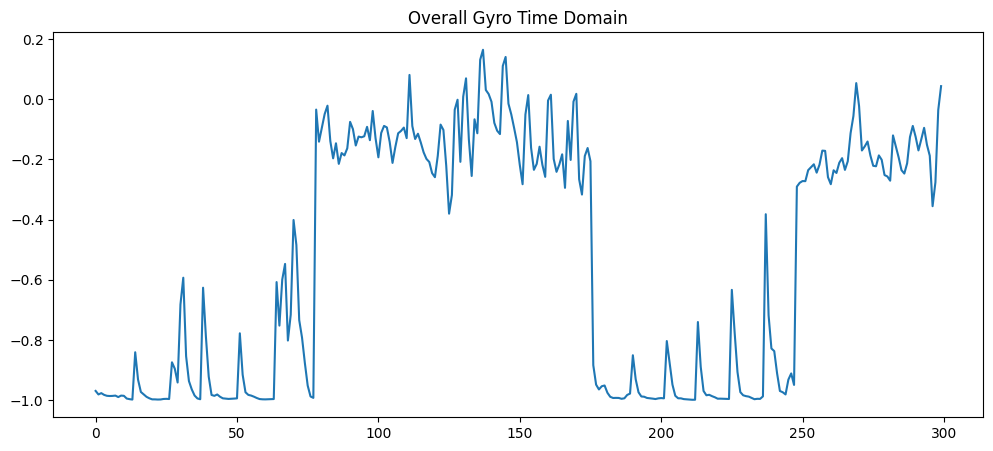

In [ ]:
# Plot overall gyro signals over time
plt.figure(figsize=(12, 5))
plt.plot(df['tBodyGyroMag-mean()'][:300], label='tBodyGyroMag-mean()')
plt.title('Overall Gyro Time Domain')
plt.show()

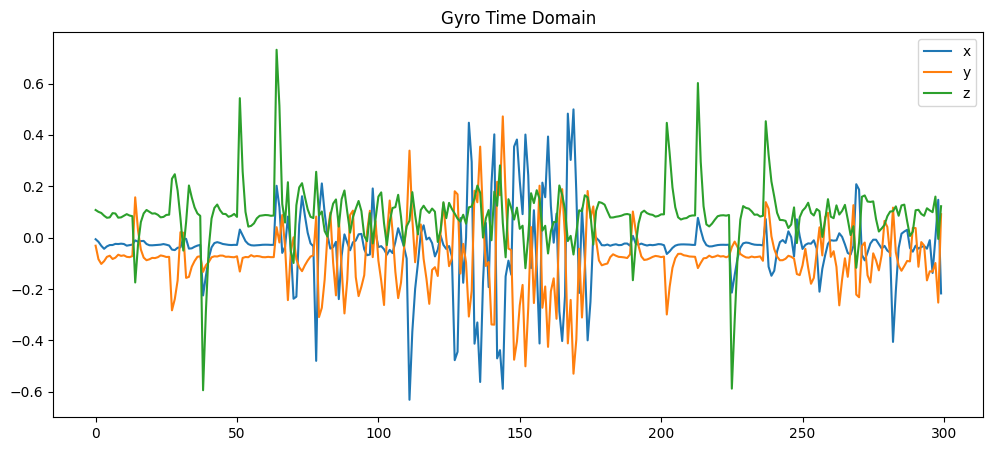

In [ ]:
# Plot gyro signals over time
plt.figure(figsize=(12, 5))
plt.plot(df['tBodyGyro-mean()-X'][:300], label='tBodyGyro-mean()-X')
plt.plot(df['tBodyGyro-mean()-Y'][:300], label='tBodyGyro-mean()-Y')
plt.plot(df['tBodyGyro-mean()-Z'][:300], label='tBodyGyro-mean()-Z')
plt.legend(['x', 'y', 'z'])
plt.title('Gyro Time Domain')
plt.show()

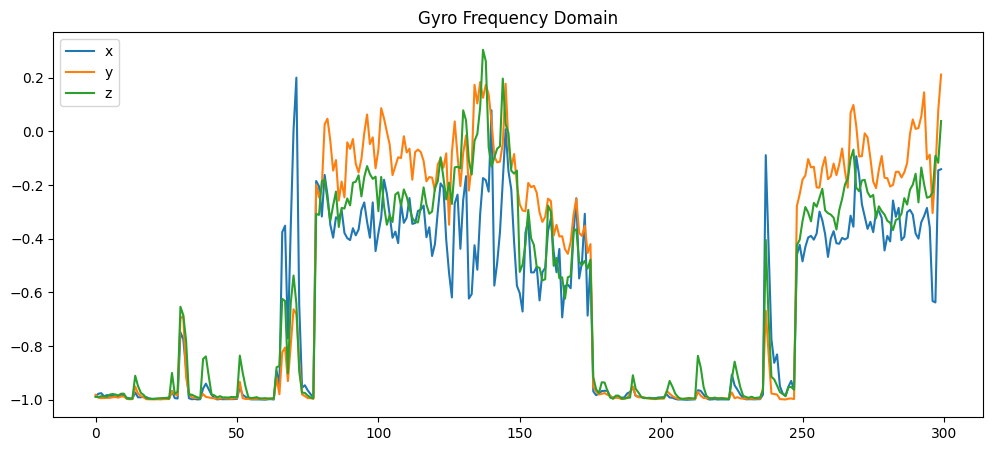

In [ ]:
# Plot gyro signals in frequency domain
plt.figure(figsize=(12, 5))
plt.plot(df['fBodyGyro-mean()-X'][:300], label='fBodyGyro-mean()-X')
plt.plot(df['fBodyGyro-mean()-Y'][:300], label='fBodyGyro-mean()-Y')
plt.plot(df['fBodyGyro-mean()-Z'][:300], label='fBodyGyro-mean()-Z')
plt.legend(['x', 'y', 'z'])
plt.title('Gyro Frequency Domain')
plt.show()

In [ ]:
train = pd.read_csv('train.csv')
test = pd.read_csv('test.csv')

train.dropna(inplace=True)
test.dropna(inplace=True)

X_train = train.drop(['subject', 'Activity', 'Activity_name'], axis=1)
y_train = train['Activity']
X_test = test.drop(['subject', 'Activity', 'Activity_name'], axis=1)
y_test = test['Activity']

In [ ]:
X_train.shape, y_train.shape, X_test.shape, y_test.shape

((7352, 561), (7352,), (2947, 561), (2947,))

## KNN & Naive Bayes



In [ ]:
# KNN
knn = KNeighborsClassifier(n_neighbors=5)
knn.fit(X_train, y_train)

knn_pred = knn.predict(X_test)
knn_proba = knn.predict_proba(X_test)

knn_accuracy = accuracy_score(y_test, knn_pred)
knn_f1 = f1_score(y_test, knn_pred, average='weighted')
knn_roc = roc_auc_score(y_test, knn_proba, multi_class='ovr')


print("KNN Accuracy: ", knn_accuracy)
print("KNN F1 Score: ", knn_f1)
print("KNN ROC AUC:  ", knn_roc)

# NB
gnb = GaussianNB()
gnb.fit(X_train, y_train)

gnb_pred = gnb.predict(X_test)
gnb_proba = gnb.predict_proba(X_test)

gnb_accuracy = accuracy_score(y_test, gnb_pred)
gnb_f1 = f1_score(y_test, gnb_pred, average='weighted')
gnb_roc = roc_auc_score(y_test, gnb_proba, multi_class='ovr')

print("Naive Bayes Accuracy: ", gnb_accuracy)
print("Naive Bayes F1 Score: ", gnb_f1)
print("Naive Bayes ROC AUC:  ", gnb_roc)

KNN Accuracy:  0.9015948422124194
KNN F1 Score:  0.9006983259628749
KNN ROC AUC:   0.9799100556536308
Naive Bayes Accuracy:  0.7702748557855447
Naive Bayes F1 Score:  0.7687700182193763
Naive Bayes ROC AUC:   0.9577721292103362


### Confusion Matrices

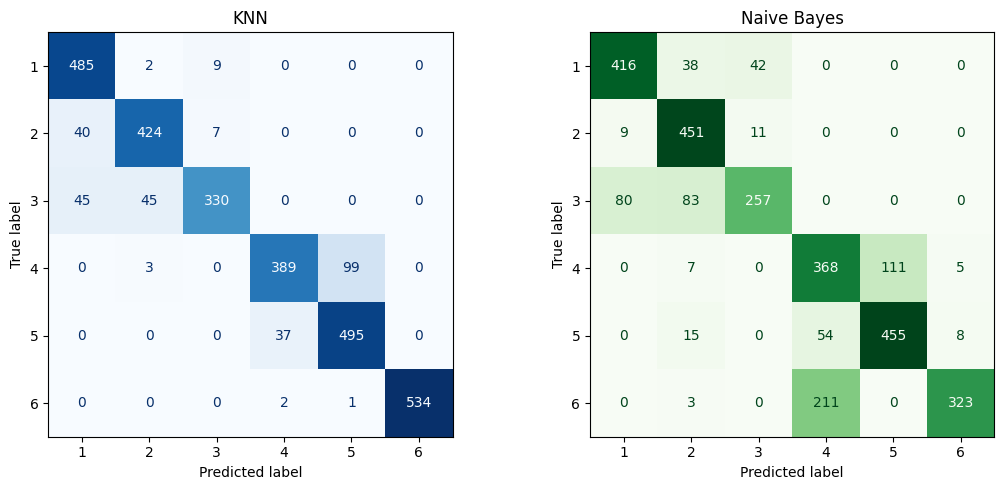

In [ ]:
fig, axes = plt.subplots(1, 2, figsize=(11, 5))

ConfusionMatrixDisplay.from_predictions(
    y_test,
    knn_pred,
    ax=axes[0],
    cmap='Blues',
    colorbar=False
)
axes[0].set_title('KNN')

ConfusionMatrixDisplay.from_predictions(
    y_test,
    gnb_pred,
    ax=axes[1],
    cmap='Greens',
    colorbar=False
)
axes[1].set_title('Naive Bayes')

plt.tight_layout()
plt.show()

### Performance Comparasion

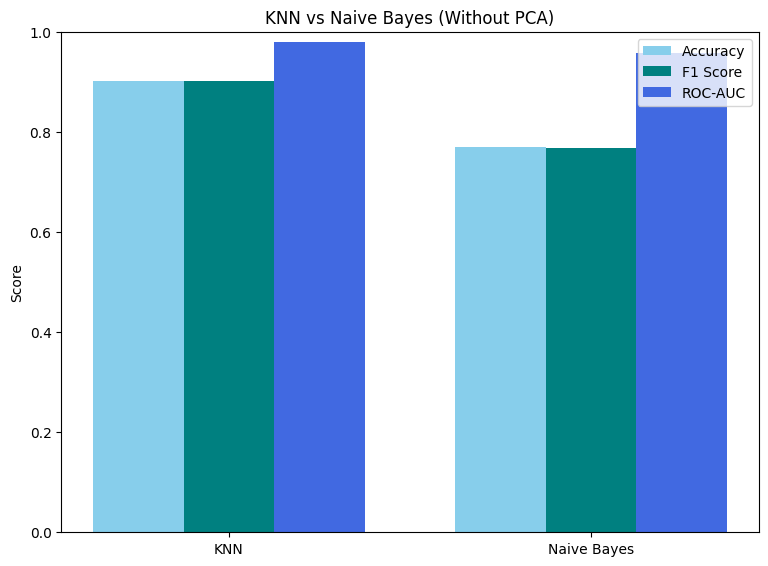

In [ ]:
models = ['KNN', 'Naive Bayes']
accuracy = [knn_accuracy, gnb_accuracy]
f1_scores = [knn_f1, gnb_f1]
roc_auc = [knn_roc, gnb_roc]

x = np.arange(len(models))
width = 0.25

plt.figure(figsize=(9,6.5))

plt.bar(x - width, accuracy, width, label='Accuracy', color='skyblue')
plt.bar(x, f1_scores, width, label='F1 Score', color='teal')
plt.bar(x + width, roc_auc, width, label='ROC-AUC', color='royalblue')

plt.xticks(x, models)
plt.ylabel("Score")
plt.title("KNN vs Naive Bayes (Without PCA)")
plt.ylim(0,1)
plt.legend()

plt.show()

## PCA

In [ ]:
from sklearn.decomposition import PCA
from sklearn.preprocessing import StandardScaler

In [ ]:
scaler = StandardScaler()
X_train_scaled = scaler.fit_transform(X_train)
X_test_scaled = scaler.transform(X_test)


In [ ]:
pca = PCA(n_components=0.95)
X_train_pca = pca.fit_transform(X_train_scaled)
X_test_pca = pca.transform(X_test_scaled)

### PCA — Explained Variance Plot


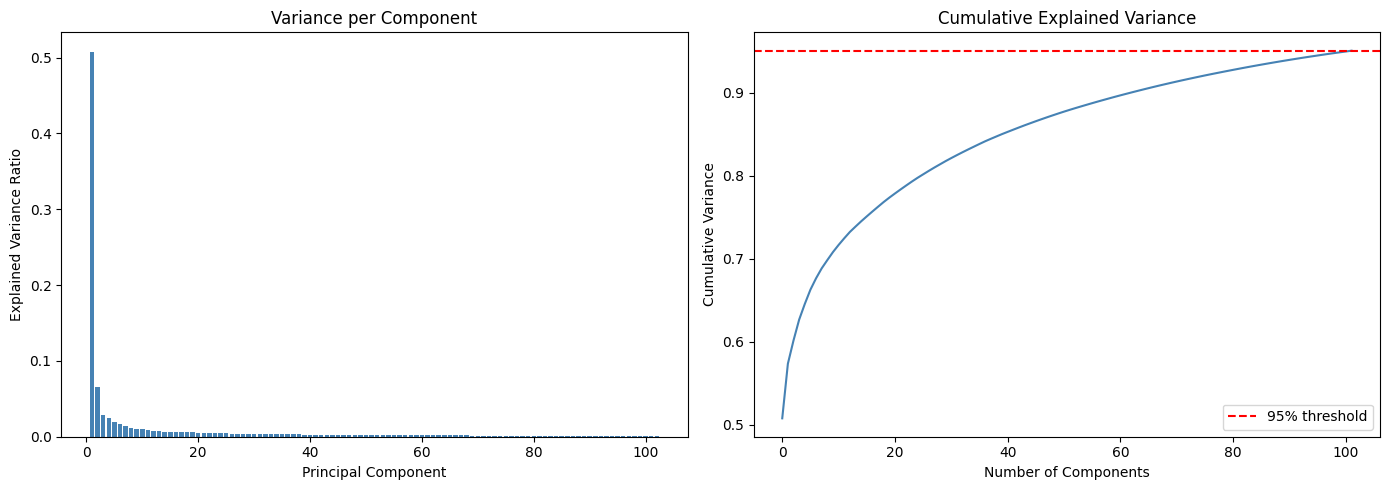

Original features                        : 561
Components for 95% var                   : 102
Components selected by PCA (95% variance): 102


In [ ]:
explained  = pca.explained_variance_ratio_
cumulative = np.cumsum(explained)

fig, axes = plt.subplots(1, 2, figsize=(14, 5))

# Left: variance per component
axes[0].bar(range(1, len(explained)+1), explained, color="steelblue")
axes[0].set_title("Variance per Component")
axes[0].set_xlabel("Principal Component")
axes[0].set_ylabel("Explained Variance Ratio")

# Right: cumulative variance
axes[1].plot(cumulative, color="steelblue")
axes[1].axhline(y=0.95, color="red", linestyle="--", label="95% threshold")
axes[1].set_title("Cumulative Explained Variance")
axes[1].set_xlabel("Number of Components")
axes[1].set_ylabel("Cumulative Variance")
axes[1].legend()

plt.tight_layout()
plt.show()

n_95 = np.argmax(cumulative >= 0.95) + 1
print(f"Original features                        : {X_train_scaled.shape[1]}")
print(f"Components for 95% var                   : {n_95}")
print(f"Components selected by PCA (95% variance): {pca.n_components_}")

PCA — 2D Scatter Plot

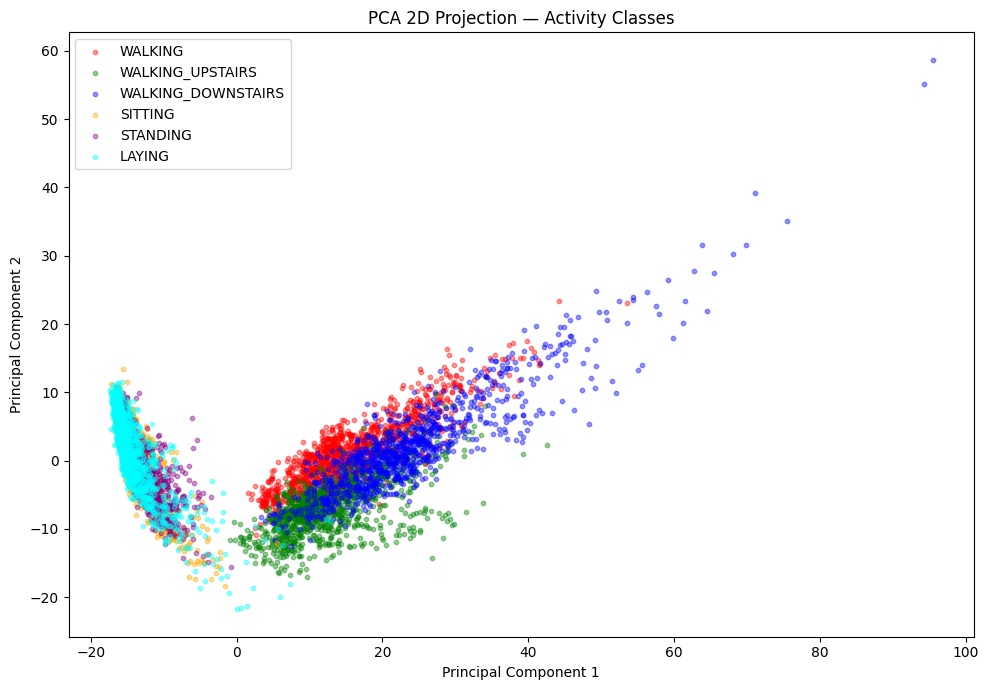

In [ ]:
pca_2d = PCA(n_components=2)
X_pca_2d = pca_2d.fit_transform(X_train_scaled)

activity_names = {
    1: "WALKING", 2: "WALKING_UPSTAIRS", 3: "WALKING_DOWNSTAIRS",
    4: "SITTING", 5: "STANDING", 6: "LAYING"
}
colors = ["red", "green", "blue", "orange", "purple", "cyan"]

plt.figure(figsize=(10, 7))
for i, (act_id, act_name) in enumerate(activity_names.items()):
    mask = (y_train == act_id)
    plt.scatter(X_pca_2d[mask, 0], X_pca_2d[mask, 1],
                c=colors[i], label=act_name, alpha=0.4, s=10)

plt.title("PCA 2D Projection — Activity Classes")
plt.xlabel("Principal Component 1")
plt.ylabel("Principal Component 2")
plt.legend(loc="best")
plt.tight_layout()
plt.show()

## KNN &  Naive Bayes (With PCA)

In [ ]:
# KNN
knn = KNeighborsClassifier(n_neighbors=5)
knn.fit(X_train_pca, y_train)

knn_pred = knn.predict(X_test_pca)
knn_proba = knn.predict_proba(X_test_pca)

knn_accuracy = accuracy_score(y_test, knn_pred)
knn_f1 = f1_score(y_test, knn_pred, average='weighted')
knn_roc = roc_auc_score(y_test, knn_proba, multi_class='ovr')


print("KNN Accuracy: ", knn_accuracy)
print("KNN F1 Score: ", knn_f1)
print("KNN ROC AUC:  ", knn_roc)

# NB
gnb = GaussianNB()
gnb.fit(X_train_pca, y_train)

gnb_pred = gnb.predict(X_test_pca)
gnb_proba = gnb.predict_proba(X_test_pca)

gnb_accuracy = accuracy_score(y_test, gnb_pred)
gnb_f1 = f1_score(y_test, gnb_pred, average='weighted')
gnb_roc = roc_auc_score(y_test, gnb_proba, multi_class='ovr')

print("Naive Bayes Accuracy: ", gnb_accuracy)
print("Naive Bayes F1 Score: ", gnb_f1)
print("Naive Bayes ROC AUC:  ", gnb_roc)

KNN Accuracy:  0.8744485917882593
KNN F1 Score:  0.8736526709149911
KNN ROC AUC:   0.9728221962131806
Naive Bayes Accuracy:  0.8045469969460468
Naive Bayes F1 Score:  0.8020345448132303
Naive Bayes ROC AUC:   0.96108091530547


### Confusion Matrices

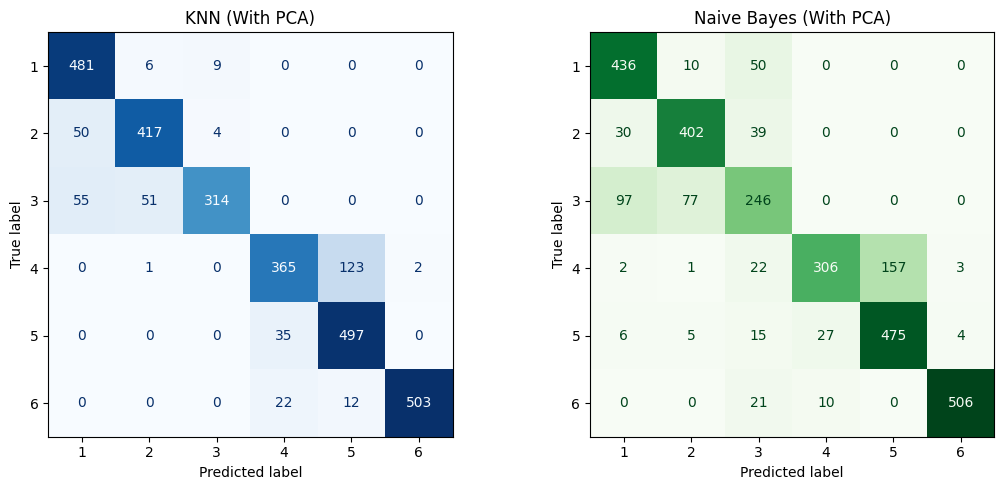

In [ ]:
fig, axes = plt.subplots(1, 2, figsize=(11, 5))

ConfusionMatrixDisplay.from_predictions(
    y_test,
    knn_pred,
    ax=axes[0],
    cmap='Blues',
    colorbar=False
)
axes[0].set_title('KNN (With PCA)')

ConfusionMatrixDisplay.from_predictions(
    y_test,
    gnb_pred,
    ax=axes[1],
    cmap='Greens',
    colorbar=False
)
axes[1].set_title('Naive Bayes (With PCA)')

plt.tight_layout()
plt.show()

###Performance Comparasion

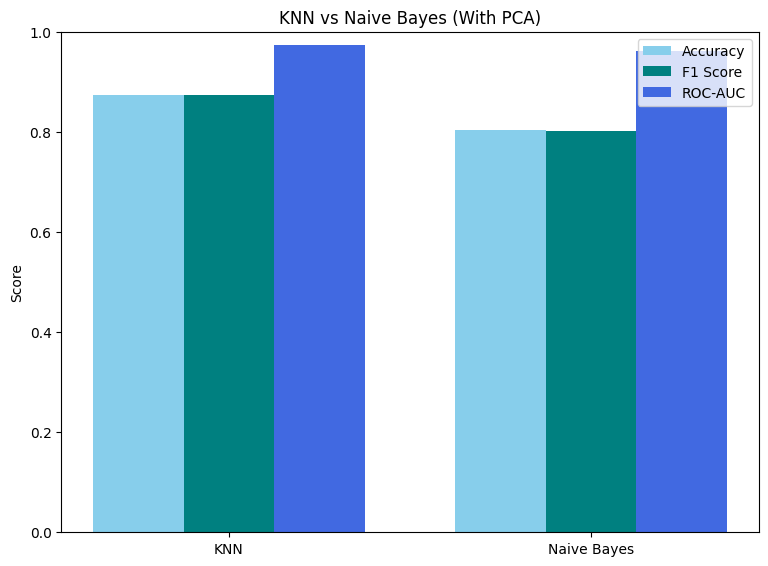

In [ ]:
models = ['KNN', 'Naive Bayes']
accuracy = [knn_accuracy, gnb_accuracy]
f1_scores = [knn_f1, gnb_f1]
roc_auc = [knn_roc, gnb_roc]

x = np.arange(len(models))
width = 0.25

plt.figure(figsize=(9,6.5))

plt.bar(x - width, accuracy, width, label='Accuracy', color='skyblue')
plt.bar(x, f1_scores, width, label='F1 Score', color='teal')
plt.bar(x + width, roc_auc, width, label='ROC-AUC', color='royalblue')

plt.xticks(x, models)
plt.ylabel("Score")
plt.title("KNN vs Naive Bayes (With PCA)")
plt.ylim(0,1)
plt.legend()

plt.show()

## Ensemble & Hyperparameter Tuning

### Random Forest

In [ ]:
rf = RandomForestClassifier(n_jobs=-1)

rf_params = {
    'n_estimators': [100],
    'max_depth': [10, None],
    'min_samples_split': [2, 5]
}

rf_grid = GridSearchCV(rf, rf_params, cv=5, scoring='accuracy')
rf_grid.fit(X_train_pca, y_train)

best_rf = rf_grid.best_estimator_

rf_pred = best_rf.predict(X_test_pca)
rf_proba = best_rf.predict_proba(X_test_pca)

rf_accuracy = accuracy_score(y_test, rf_pred)
rf_f1 = f1_score(y_test, rf_pred, average='weighted')
rf_roc = roc_auc_score(y_test, rf_proba, multi_class='ovr')

print("Random Forest Accuracy:", rf_accuracy)
print("Random Forest F1 Score:", rf_f1)
print("Random Forest ROC AUC:", rf_roc)

Random Forest Accuracy: 0.8832711231761113
Random Forest F1 Score: 0.882326851258464
Random Forest ROC AUC: 0.990336030545933


### Gradient Boosting

In [ ]:
gb = GradientBoostingClassifier(n_estimators=100)

gb_params = {
    'n_estimators': [100],
    'learning_rate': [0.1],
    'max_depth': [3]
}

gb_grid = GridSearchCV(gb, gb_params, cv=5, scoring='accuracy')
gb_grid.fit(X_train_pca, y_train)

best_gb = gb_grid.best_estimator_

gb_pred = best_gb.predict(X_test_pca)
gb_proba = best_gb.predict_proba(X_test_pca)

gb_accuracy = accuracy_score(y_test, gb_pred)
gb_f1 = f1_score(y_test, gb_pred, average='weighted')
gb_roc = roc_auc_score(y_test, gb_proba, multi_class='ovr')

print("Gradient Boosting Accuracy:", gb_accuracy)
print("Gradient Boosting F1 Score:", gb_f1)
print("Gradient Boosting ROC AUC:", gb_roc)

Gradient Boosting Accuracy: 0.9032914828639295
Gradient Boosting F1 Score: 0.9021754569263998
Gradient Boosting ROC AUC: 0.9924000757334627


### Cross Evaluation

In [ ]:
rf_cv_scores = cross_val_score(best_rf, X_train_pca, y_train, cv=5, scoring='accuracy')
print("Random Forest Cross Validation Accuracy:", rf_cv_scores.mean())

gb_cv_scores = cross_val_score(best_gb, X_train_pca, y_train, cv=5, scoring='accuracy')
print("Gradient Boosting Cross Validation Accuracy:", gb_cv_scores.mean())

Random Forest Cross Validation Accuracy: 0.8571829057931806
Gradient Boosting Cross Validation Accuracy: 0.8619474003061456


### Comparasion

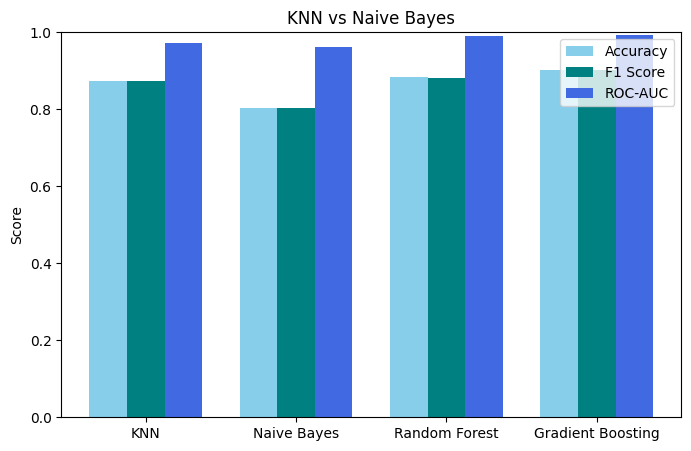

In [ ]:
models = ['KNN', 'Naive Bayes', 'Random Forest', 'Gradient Boosting']

accuracy = [knn_accuracy, gnb_accuracy, rf_accuracy, gb_accuracy]
f1_scores = [knn_f1, gnb_f1, rf_f1, gb_f1]
roc_auc = [knn_roc, gnb_roc, rf_roc, gb_roc]

x = np.arange(len(models))
width = 0.25

plt.figure(figsize=(8,5))

plt.bar(x - width, accuracy, width, label='Accuracy', color='skyblue')
plt.bar(x, f1_scores, width, label='F1 Score', color='teal')
plt.bar(x + width, roc_auc, width, label='ROC-AUC', color='royalblue')

plt.xticks(x, models)
plt.ylabel("Score")
plt.title("KNN vs Naive Bayes")
plt.ylim(0,1)
plt.legend()

plt.show()

# Phase 2


## CNN

In [ ]:
import numpy as np
import os

def load_signals(folder_path,kind="train"):
    signals = []

    file_names = [
        f"body_acc_x_{kind}.txt",
        f"body_acc_y_{kind}.txt",
        f"body_acc_z_{kind}.txt",
        f"body_gyro_x_{kind}.txt",
        f"body_gyro_y_{kind}.txt",
        f"body_gyro_z_{kind}.txt",
        f"total_acc_x_{kind}.txt",
        f"total_acc_y_{kind}.txt",
        f"total_acc_z_{kind}.txt"
    ]

    for file in file_names:
        data = np.loadtxt(os.path.join(folder_path, file))
        signals.append(data)

    signals = np.transpose(signals, (1, 2, 0))  # (samples, 128, 9)
    return signals

X_train = load_signals("/content/Dataset/train/Inertial Signals", kind="train")
X_test  = load_signals("/content/Dataset/test/Inertial Signals", kind="test")

print(X_train.shape)  # (7352, 128, 9)

(7352, 128, 9)


In [ ]:
# ====== LOAD LABELS ======
from tensorflow.keras.utils import to_categorical

y_train = pd.read_csv("/content/Dataset/train/y_train.txt", header=None).values - 1
y_test  = pd.read_csv("/content/Dataset/test/y_test.txt", header=None).values - 1



In [ ]:
y_train

array([[4],
       [4],
       [4],
       ...,
       [1],
       [1],
       [1]])

In [ ]:
from sklearn.preprocessing import StandardScaler

scaler = StandardScaler()

X_train_2d = X_train.reshape(-1, 9)
X_test_2d  = X_test.reshape(-1, 9)

X_train_2d = scaler.fit_transform(X_train_2d)
X_test_2d  = scaler.transform(X_test_2d)

X_train = X_train_2d.reshape(-1, 128, 9)
X_test  = X_test_2d.reshape(-1, 128, 9)

In [ ]:


def build_cnn(optimizer='adam'):
    model = Sequential([
        Conv1D(64, 3, activation='relu', input_shape=(128, 9)),
        MaxPooling1D(2),

        Conv1D(128, 3, activation='relu'),
        MaxPooling1D(2),

        Flatten(),
        Dense(100, activation='relu'),
        Dropout(0.5),

        Dense(6, activation='softmax')
    ])

    model.compile(
        optimizer=optimizer,
        loss='sparse_categorical_crossentropy',
        metrics=['accuracy']
    )
    return model

In [ ]:
from tensorflow.keras.optimizers import SGD
# classificaiotn report
from sklearn.metrics import classification_report

# Adam
model_adam = build_cnn(optimizer='adam')
history_adam = model_adam.fit(X_train, y_train,
                             epochs=10,
                             batch_size=64,
                             validation_data=(X_test, y_test))



# SGD with momentum
model_sgd = build_cnn(optimizer=SGD(learning_rate=0.01, momentum=0.9))
history_sgd = model_sgd.fit(X_train, y_train,
                           epochs=10,
                           batch_size=64,
                           validation_data=(X_test, y_test))


/usr/local/lib/python3.12/dist-packages/keras/src/layers/convolutional/base_conv.py:113: UserWarning: Do not pass an `input_shape`/`input_dim` argument to a layer. When using Sequential models, prefer using an `Input(shape)` object as the first layer in the model instead.
  super().__init__(activity_regularizer=activity_regularizer, **kwargs)


Epoch 1/10
115/115 ━━━━━━━━━━━━━━━━━━━━ 9s 35ms/step - accuracy: 0.8062 - loss: 0.5214 - val_accuracy: 0.9135 - val_loss: 0.2865
Epoch 2/10
115/115 ━━━━━━━━━━━━━━━━━━━━ 1s 5ms/step - accuracy: 0.9392 - loss: 0.1534 - val_accuracy: 0.8924 - val_loss: 0.3046
Epoch 3/10
115/115 ━━━━━━━━━━━━━━━━━━━━ 1s 5ms/step - accuracy: 0.9504 - loss: 0.1239 - val_accuracy: 0.9108 - val_loss: 0.2889
Epoch 4/10
115/115 ━━━━━━━━━━━━━━━━━━━━ 1s 5ms/step - accuracy: 0.9540 - loss: 0.1093 - val_accuracy: 0.9169 - val_loss: 0.2776
Epoch 5/10
115/115 ━━━━━━━━━━━━━━━━━━━━ 1s 5ms/step - accuracy: 0.9529 - loss: 0.1079 - val_accuracy: 0.9125 - val_loss: 0.3486
Epoch 6/10
115/115 ━━━━━━━━━━━━━━━━━━━━ 1s 5ms/step - accuracy: 0.9569 - loss: 0.0990 - val_accuracy: 0.9141 - val_loss: 0.3195
Epoch 7/10
115/115 ━━━━━━━━━━━━━━━━━━━━ 1s 5ms/step - accuracy: 0.9561 - loss: 0.0934 - val_accuracy: 0.9196 - val_loss: 0.3521
Epoch 8/10
115/115 ━━━━━━━━━━━━━━━━━━━━ 1s 5ms/step - accuracy: 0.9601 - loss: 0.0888 - val_accuracy: 0

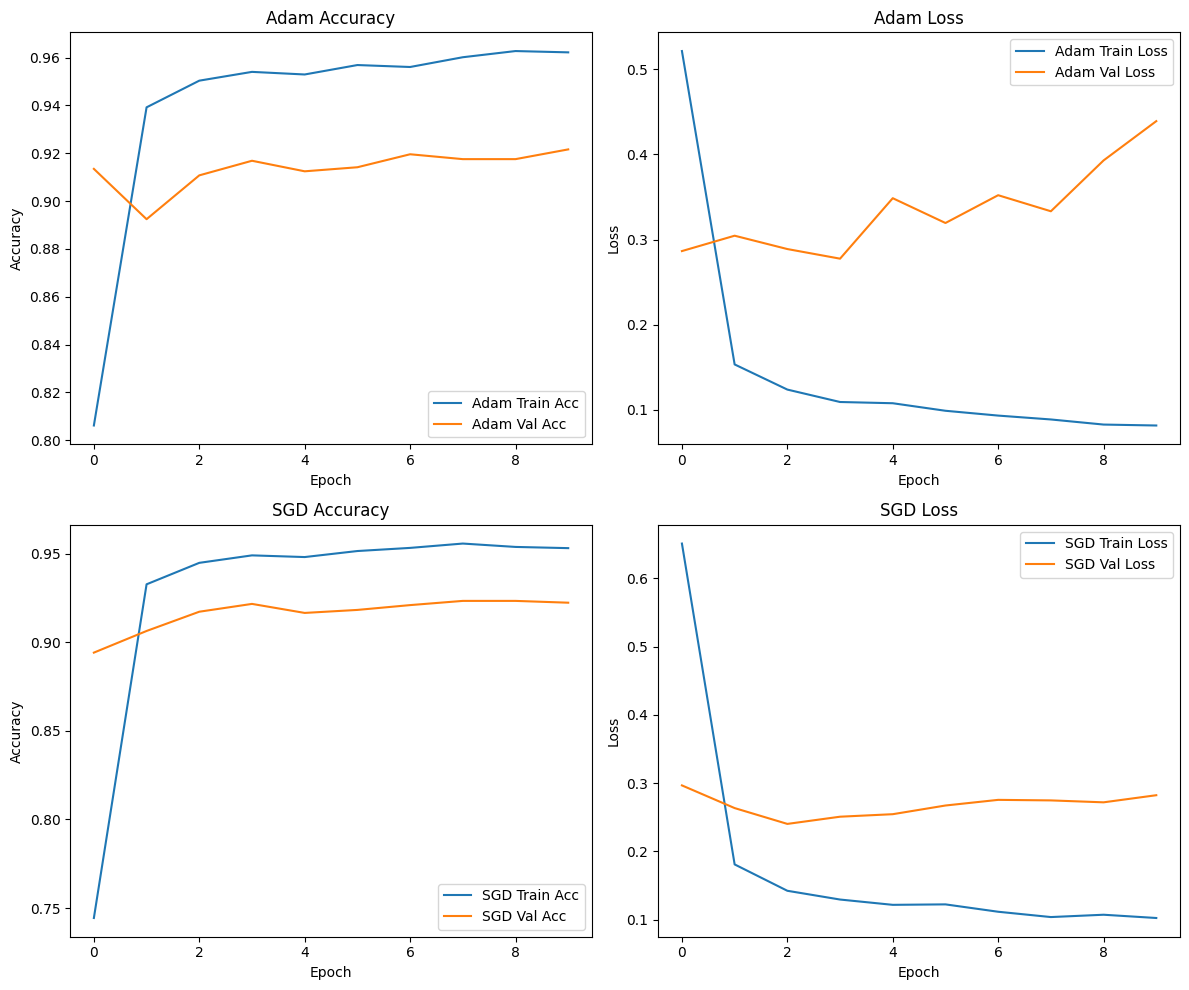

In [ ]:
# plot training history for poth   modes and acc , loss one plot for each mode and acc , loss    (4 plots in total)
plt.figure(figsize=(12, 10))
plt.subplot(2, 2, 1)
plt.plot(history_adam.history['accuracy'], label='Adam Train Acc')
plt.plot(history_adam.history['val_accuracy'], label='Adam Val Acc')
plt.title('Adam Accuracy')
plt.xlabel('Epoch')
plt.ylabel('Accuracy')
plt.legend()
plt.subplot(2, 2, 2)
plt.plot(history_adam.history['loss'], label='Adam Train Loss')
plt.plot(history_adam.history['val_loss'], label='Adam Val Loss')
plt.title('Adam Loss')
plt.xlabel('Epoch')
plt.ylabel('Loss')
plt.legend()
plt.subplot(2, 2, 3)
plt.plot(history_sgd.history['accuracy'], label='SGD Train Acc')
plt.plot(history_sgd.history['val_accuracy'], label='SGD Val Acc')
plt.title('SGD Accuracy')
plt.xlabel('Epoch')
plt.ylabel('Accuracy')
plt.legend()
plt.subplot(2, 2, 4)
plt.plot(history_sgd.history['loss'], label='SGD Train Loss')
plt.plot(history_sgd.history['val_loss'], label='SGD Val Loss')
plt.title('SGD Loss')
plt.xlabel('Epoch')
plt.ylabel('Loss')
plt.legend()
plt.tight_layout()
plt.show()

In [ ]:
from sklearn.metrics import classification_report
import numpy as np

def evaluate_model(model,x=X_test, y=y_test):
    y_pred = model.predict(x)
    y_pred = np.argmax(y_pred, axis=1)

    print(classification_report(y, y_pred))

print("=== Adam ===")
evaluate_model(model_adam)

print("=== SGD ===")
evaluate_model(model_sgd)

=== Adam ===
93/93 ━━━━━━━━━━━━━━━━━━━━ 1s 5ms/step
              precision    recall  f1-score   support

           0       1.00      0.95      0.97       496
           1       0.97      0.90      0.94       471
           2       0.86      1.00      0.92       420
           3       0.86      0.81      0.84       491
           4       0.85      0.87      0.86       532
           5       1.00      1.00      1.00       537

    accuracy                           0.92      2947
   macro avg       0.92      0.92      0.92      2947
weighted avg       0.92      0.92      0.92      2947

=== SGD ===
93/93 ━━━━━━━━━━━━━━━━━━━━ 1s 5ms/step
              precision    recall  f1-score   support

           0       1.00      0.99      0.99       496
           1       0.98      0.94      0.96       471
           2       0.93      0.99      0.96       420
           3       0.82      0.78      0.80       491
           4       0.82      0.85      0.83       532
           5       0.99      

In [ ]:
model_adam.summary()

Model: "sequential"

┏━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━┓
┃ Layer (type)                    ┃ Output Shape           ┃       Param # ┃
┡━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━┩
│ conv1d (Conv1D)                 │ (None, 126, 64)        │         1,792 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ max_pooling1d (MaxPooling1D)    │ (None, 63, 64)         │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ conv1d_1 (Conv1D)               │ (None, 61, 128)        │        24,704 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ max_pooling1d_1 (MaxPooling1D)  │ (None, 30, 128)        │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ flatten (Flatten)               │ (None, 3840)           │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dense (Dense)                   │ (None, 100)            │       384,100 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dropout (Dropout)               │ (None, 100)            │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dense_1 (Dense)                 │ (None, 6)              │           606 │
└─────────────────────────────────┴────────────────────────┴───────────────┘

 Total params: 1,233,608 (4.71 MB)

 Trainable params: 411,202 (1.57 MB)

 Non-trainable params: 0 (0.00 B)

 Optimizer params: 822,406 (3.14 MB)

In [ ]:
model_sgd.summary()

Model: "sequential_1"

┏━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━┓
┃ Layer (type)                    ┃ Output Shape           ┃       Param # ┃
┡━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━┩
│ conv1d_2 (Conv1D)               │ (None, 126, 64)        │         1,792 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ max_pooling1d_2 (MaxPooling1D)  │ (None, 63, 64)         │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ conv1d_3 (Conv1D)               │ (None, 61, 128)        │        24,704 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ max_pooling1d_3 (MaxPooling1D)  │ (None, 30, 128)        │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ flatten_1 (Flatten)             │ (None, 3840)           │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dense_2 (Dense)                 │ (None, 100)            │       384,100 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dropout_1 (Dropout)             │ (None, 100)            │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dense_3 (Dense)                 │ (None, 6)              │           606 │
└─────────────────────────────────┴────────────────────────┴───────────────┘

 Total params: 822,406 (3.14 MB)

 Trainable params: 411,202 (1.57 MB)

 Non-trainable params: 0 (0.00 B)

 Optimizer params: 411,204 (1.57 MB)

## Auto encoder anommly deteciton

In [ ]:
input_layer = Input(shape=(128, 9))

encoded = Conv1D(32, 3, activation='relu', padding='same')(input_layer)
encoded = Conv1D(16, 3, activation='relu', padding='same')(encoded)

decoded = Conv1D(32, 3, activation='relu', padding='same')(encoded)
decoded = Conv1D(9, 3, activation='sigmoid', padding='same')(decoded)

autoencoder = Model(input_layer, decoded)

autoencoder.compile(optimizer='adam', loss='mse')

autoencoder.fit(X_train, X_train,
                epochs=10,
                batch_size=64,
                validation_data=(X_test, X_test))

Epoch 1/10
115/115 ━━━━━━━━━━━━━━━━━━━━ 5s 22ms/step - loss: 0.9015 - val_loss: 0.6832
Epoch 2/10
115/115 ━━━━━━━━━━━━━━━━━━━━ 1s 5ms/step - loss: 0.7323 - val_loss: 0.6601
Epoch 3/10
115/115 ━━━━━━━━━━━━━━━━━━━━ 1s 5ms/step - loss: 0.7231 - val_loss: 0.6554
Epoch 4/10
115/115 ━━━━━━━━━━━━━━━━━━━━ 1s 4ms/step - loss: 0.6985 - val_loss: 0.6178
Epoch 5/10
115/115 ━━━━━━━━━━━━━━━━━━━━ 1s 4ms/step - loss: 0.6803 - val_loss: 0.6154
Epoch 6/10
115/115 ━━━━━━━━━━━━━━━━━━━━ 1s 5ms/step - loss: 0.6786 - val_loss: 0.6140
Epoch 7/10
115/115 ━━━━━━━━━━━━━━━━━━━━ 1s 5ms/step - loss: 0.6776 - val_loss: 0.6131
Epoch 8/10
115/115 ━━━━━━━━━━━━━━━━━━━━ 1s 5ms/step - loss: 0.6768 - val_loss: 0.6123
Epoch 9/10
115/115 ━━━━━━━━━━━━━━━━━━━━ 1s 5ms/step - loss: 0.6762 - val_loss: 0.6118
Epoch 10/10
115/115 ━━━━━━━━━━━━━━━━━━━━ 1s 6ms/step - loss: 0.6758 - val_loss: 0.6114


In [ ]:
recon = autoencoder.predict(X_test)
mse = np.mean(np.square(X_test - recon), axis=(1,2))

threshold = np.percentile(mse, 95)

anomalies = mse > threshold
print("Number of anomalies:", np.sum(anomalies))

93/93 ━━━━━━━━━━━━━━━━━━━━ 1s 6ms/step
Number of anomalies: 148


## Transfer learning

In [ ]:
y_train = y_train.flatten()
subject_train = subject_train.values.flatten()

In [ ]:

# subject split
X_sub1 = X_train[subject_train == 1]
y_sub1 = y_train[subject_train == 1]

X_sub3 = X_train[subject_train == 3]
y_sub3 = y_train[subject_train == 3]


In [ ]:

# Train
model_transfer = build_cnn()
model_transfer.fit(X_sub1, y_sub1, epochs=5, batch_size=32)


Epoch 1/5


/usr/local/lib/python3.12/dist-packages/keras/src/layers/convolutional/base_conv.py:113: UserWarning: Do not pass an `input_shape`/`input_dim` argument to a layer. When using Sequential models, prefer using an `Input(shape)` object as the first layer in the model instead.
  super().__init__(activity_regularizer=activity_regularizer, **kwargs)


11/11 ━━━━━━━━━━━━━━━━━━━━ 5s 188ms/step - accuracy: 0.3833 - loss: 1.3547
Epoch 2/5
11/11 ━━━━━━━━━━━━━━━━━━━━ 0s 5ms/step - accuracy: 0.7867 - loss: 0.8026 
Epoch 3/5
11/11 ━━━━━━━━━━━━━━━━━━━━ 0s 5ms/step - accuracy: 0.8905 - loss: 0.4626 
Epoch 4/5
11/11 ━━━━━━━━━━━━━━━━━━━━ 0s 5ms/step - accuracy: 0.9597 - loss: 0.2047 
Epoch 5/5
11/11 ━━━━━━━━━━━━━━━━━━━━ 0s 5ms/step - accuracy: 0.9856 - loss: 0.0854 


In [ ]:
# Freeze
for layer in model_transfer.layers[:-3]:
    layer.trainable = False


In [ ]:
# Recompile
model_transfer.compile(
    optimizer='adam',
    loss='sparse_categorical_crossentropy',
    metrics=['accuracy']
)

In [ ]:
# Fine-tuning
model_transfer.fit(X_sub3, y_sub3, epochs=5, batch_size=32)


Epoch 1/5
11/11 ━━━━━━━━━━━━━━━━━━━━ 3s 133ms/step - accuracy: 0.7713 - loss: 0.6783
Epoch 2/5
11/11 ━━━━━━━━━━━━━━━━━━━━ 0s 5ms/step - accuracy: 0.8944 - loss: 0.3591 
Epoch 3/5
11/11 ━━━━━━━━━━━━━━━━━━━━ 0s 5ms/step - accuracy: 0.9443 - loss: 0.2064 
Epoch 4/5
11/11 ━━━━━━━━━━━━━━━━━━━━ 0s 5ms/step - accuracy: 0.9589 - loss: 0.1431 
Epoch 5/5
11/11 ━━━━━━━━━━━━━━━━━━━━ 0s 6ms/step - accuracy: 0.9707 - loss: 0.1125 


In [ ]:
model_transfer.summary()

Model: "sequential_2"

┏━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━┓
┃ Layer (type)                    ┃ Output Shape           ┃       Param # ┃
┡━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━┩
│ conv1d_8 (Conv1D)               │ (None, 126, 64)        │         1,792 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ max_pooling1d_4 (MaxPooling1D)  │ (None, 63, 64)         │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ conv1d_9 (Conv1D)               │ (None, 61, 128)        │        24,704 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ max_pooling1d_5 (MaxPooling1D)  │ (None, 30, 128)        │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ flatten_2 (Flatten)             │ (None, 3840)           │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dense_4 (Dense)                 │ (None, 100)            │       384,100 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dropout_2 (Dropout)             │ (None, 100)            │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dense_5 (Dense)                 │ (None, 6)              │           606 │
└─────────────────────────────────┴────────────────────────┴───────────────┘

 Total params: 1,180,616 (4.50 MB)

 Trainable params: 384,706 (1.47 MB)

 Non-trainable params: 26,496 (103.50 KB)

 Optimizer params: 769,414 (2.94 MB)

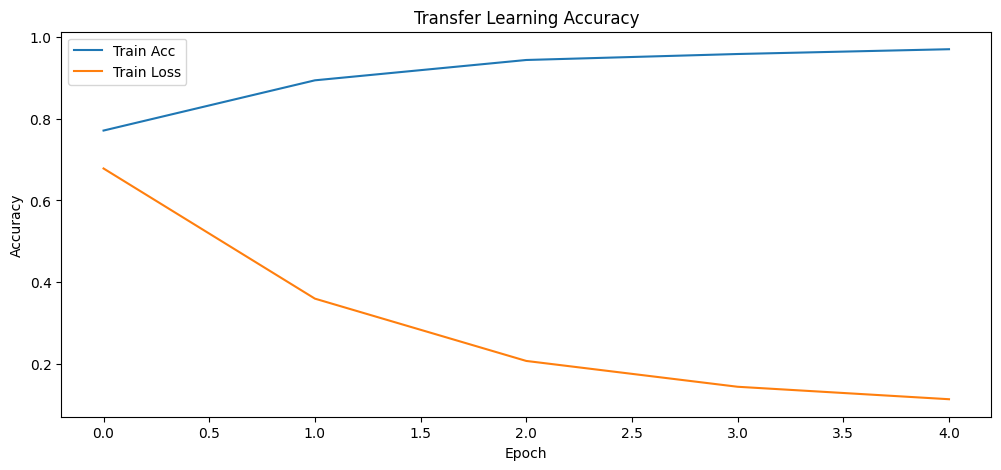

In [ ]:
#plot fine tuning history
plt.figure(figsize=(12, 5))
plt.plot(model_transfer.history.history['accuracy'], label='Train Acc')
plt.plot(model_transfer.history.history['loss'], label='Train Loss')
plt.title('Transfer Learning Accuracy')
plt.xlabel('Epoch')
plt.ylabel('Accuracy')
plt.legend()
plt.show()


In [ ]:
# Evaluate
evaluate_model(model_transfer, x=X_sub3, y=y_sub3)

11/11 ━━━━━━━━━━━━━━━━━━━━ 1s 29ms/step
              precision    recall  f1-score   support

           0       1.00      1.00      1.00        58
           1       1.00      1.00      1.00        59
           2       1.00      1.00      1.00        49
           3       1.00      1.00      1.00        52
           4       1.00      1.00      1.00        61
           5       1.00      1.00      1.00        62

    accuracy                           1.00       341
   macro avg       1.00      1.00      1.00       341
weighted avg       1.00      1.00      1.00       341



# Phase 3

## RNN

In [ ]:
from tensorflow.keras.layers import SimpleRNN
from tensorflow.keras.callbacks import EarlyStopping
import time

X_train_rnn = X_train
X_test_rnn  = X_test

y_train_rnn = np.array(y_train).flatten()
y_test_rnn  = np.array(y_test).flatten()

print("X_train:", X_train_rnn.shape)
print("X_test :", X_test_rnn.shape)
print("y_train:", y_train_rnn.shape)
print("y_test :", y_test_rnn.shape)

activity_names = ['WALKING', 'WALKING_UPSTAIRS', 'WALKING_DOWNSTAIRS',
                  'SITTING', 'STANDING', 'LAYING']

X_train: (7352, 128, 9)
X_test : (2947, 128, 9)
y_train: (7352,)
y_test : (2947,)


### Build & Train Vanilla RNN

In [ ]:
rnn_model = Sequential([
    SimpleRNN(64, return_sequences=True, input_shape=(128, 9)),
    Dropout(0.3),
    SimpleRNN(32),
    Dropout(0.3),
    Dense(6, activation='softmax')
])

rnn_model.compile(optimizer='adam',
                  loss='sparse_categorical_crossentropy',
                  metrics=['accuracy'])

rnn_model.summary()

early_stop = EarlyStopping(monitor='val_loss', patience=7, restore_best_weights=True)

t0 = time.time()
history = rnn_model.fit(X_train_rnn, y_train_rnn,
                        epochs=50,
                        batch_size=64,
                        validation_data=(X_test_rnn, y_test_rnn),
                        callbacks=[early_stop])
rnn_time = time.time() - t0
print(f"\nTraining time: {rnn_time:.1f} seconds")

/usr/local/lib/python3.12/dist-packages/keras/src/layers/rnn/rnn.py:199: UserWarning: Do not pass an `input_shape`/`input_dim` argument to a layer. When using Sequential models, prefer using an `Input(shape)` object as the first layer in the model instead.
  super().__init__(**kwargs)


Model: "sequential"

┏━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━┓
┃ Layer (type)                    ┃ Output Shape           ┃       Param # ┃
┡━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━┩
│ simple_rnn (SimpleRNN)          │ (None, 128, 64)        │         4,736 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dropout (Dropout)               │ (None, 128, 64)        │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ simple_rnn_1 (SimpleRNN)        │ (None, 32)             │         3,104 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dropout_1 (Dropout)             │ (None, 32)             │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dense (Dense)                   │ (None, 6)              │           198 │
└─────────────────────────────────┴────────────────────────┴───────────────┘

 Total params: 8,038 (31.40 KB)

 Trainable params: 8,038 (31.40 KB)

 Non-trainable params: 0 (0.00 B)

Epoch 1/50
115/115 ━━━━━━━━━━━━━━━━━━━━ 22s 113ms/step - accuracy: 0.5892 - loss: 1.0123 - val_accuracy: 0.6383 - val_loss: 0.7560
Epoch 2/50
115/115 ━━━━━━━━━━━━━━━━━━━━ 7s 46ms/step - accuracy: 0.6772 - loss: 0.6854 - val_accuracy: 0.6827 - val_loss: 0.7062
Epoch 3/50
115/115 ━━━━━━━━━━━━━━━━━━━━ 4s 36ms/step - accuracy: 0.6990 - loss: 0.6573 - val_accuracy: 0.7279 - val_loss: 0.6627
Epoch 4/50
115/115 ━━━━━━━━━━━━━━━━━━━━ 3s 27ms/step - accuracy: 0.7705 - loss: 0.5334 - val_accuracy: 0.7553 - val_loss: 0.6273
Epoch 5/50
115/115 ━━━━━━━━━━━━━━━━━━━━ 5s 26ms/step - accuracy: 0.8240 - loss: 0.4495 - val_accuracy: 0.7336 - val_loss: 0.8454
Epoch 6/50
115/115 ━━━━━━━━━━━━━━━━━━━━ 6s 30ms/step - accuracy: 0.8092 - loss: 0.5715 - val_accuracy: 0.8205 - val_loss: 0.5386
Epoch 7/50
115/115 ━━━━━━━━━━━━━━━━━━━━ 3s 24ms/step - accuracy: 0.8917 - loss: 0.3257 - val_accuracy: 0.8463 - val_loss: 0.5540
Epoch 8/50
115/115 ━━━━━━━━━━━━━━━━━━━━ 3s 25ms/step - accuracy: 0.6387 - loss: 1.1539 - val_ac

### RNN Training Curves

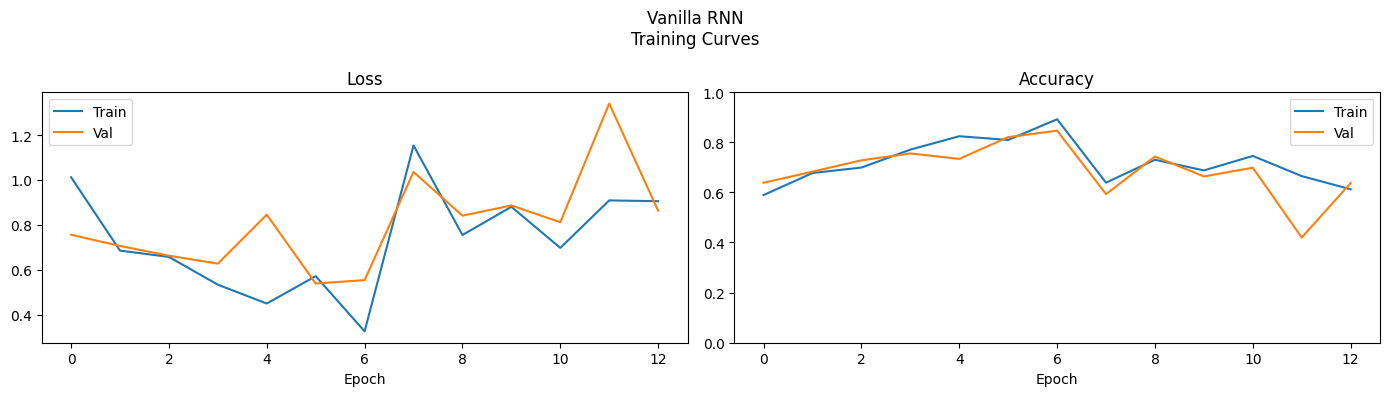

In [ ]:
fig, axes = plt.subplots(1, 2, figsize=(14, 4))

axes[0].plot(history.history['loss'],     label='Train')
axes[0].plot(history.history['val_loss'], label='Val')
axes[0].set_title('Loss')
axes[0].set_xlabel('Epoch')
axes[0].legend()

axes[1].plot(history.history['accuracy'],     label='Train')
axes[1].plot(history.history['val_accuracy'], label='Val')
axes[1].set_title('Accuracy')
axes[1].set_xlabel('Epoch')
axes[1].set_ylim(0, 1)
axes[1].legend()

plt.suptitle('Vanilla RNN\nTraining Curves')
plt.tight_layout()
plt.show()

### RNN Evaluation

Accuracy      : 0.8205
F1 (weighted) : 0.8191

Per-class F1:
  WALKING             : 0.7517
  WALKING_UPSTAIRS    : 0.7091
  WALKING_DOWNSTAIRS  : 0.8374
  SITTING             : 0.7913
  STANDING            : 0.8338
  LAYING              : 0.9742

                    precision    recall  f1-score   support

           WALKING     0.8350    0.6835    0.7517       496
  WALKING_UPSTAIRS     0.7199    0.6985    0.7091       471
WALKING_DOWNSTAIRS     0.7305    0.9810    0.8374       420
           SITTING     0.8485    0.7413    0.7913       491
          STANDING     0.7986    0.8722    0.8338       532
            LAYING     1.0000    0.9497    0.9742       537

          accuracy                         0.8205      2947
         macro avg     0.8221    0.8210    0.8162      2947
      weighted avg     0.8275    0.8205    0.8191      2947



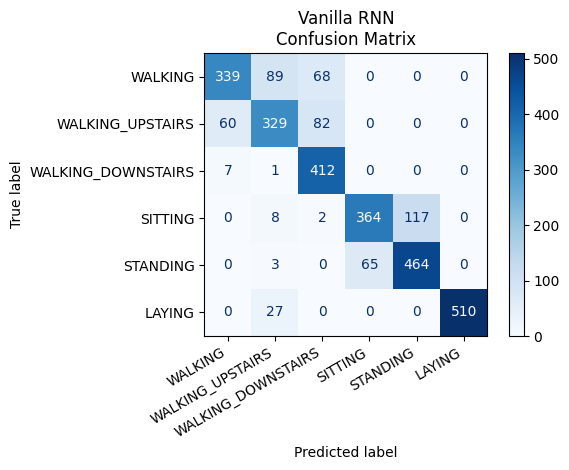

In [ ]:
rnn_loss, rnn_acc = rnn_model.evaluate(X_test_rnn, y_test_rnn, verbose=0)
y_pred = np.argmax(rnn_model.predict(X_test_rnn, verbose=0), axis=1)

rnn_f1_weighted = f1_score(y_test_rnn, y_pred, average='weighted')
rnn_f1_per_class = f1_score(y_test_rnn, y_pred, average=None)

rnn_best_val_acc = max(history.history['val_accuracy'])

print(f"Accuracy      : {rnn_acc:.4f}")
print(f"F1 (weighted) : {rnn_f1_weighted:.4f}")
print("\nPer-class F1:")
for name, score in zip(activity_names, rnn_f1_per_class):
    print(f"  {name:<20}: {score:.4f}")

print("\n" + classification_report(y_test_rnn, y_pred, target_names=activity_names, digits=4))

ConfusionMatrixDisplay.from_predictions(
    y_test_rnn, y_pred,
    display_labels=activity_names,
    cmap='Blues'
)
plt.title('Vanilla RNN\nConfusion Matrix')
plt.xticks(rotation=30, ha='right')
plt.tight_layout()
plt.show()

## GRU

### Build & Train GRU

In [ ]:
from tensorflow.keras.layers import GRU
import time

# Build GRU
model_gru = Sequential([
    GRU(128, return_sequences=True, input_shape=(128, 9)),
    Dropout(0.3),
    GRU(64),
    Dropout(0.3),
    Dense(6, activation='softmax')
])

model_gru.compile(optimizer='adam',
                  loss='sparse_categorical_crossentropy',
                  metrics=['accuracy'])

model_gru.summary()

# train
early_stop = EarlyStopping(monitor='val_loss', patience=7, restore_best_weights=True)

t0 = time.time()
history_gru = model_gru.fit(X_train, y_train.flatten(),
                            epochs=50,
                            batch_size=64,
                            validation_data=(X_test, y_test.flatten()),
                            callbacks=[early_stop])
gru_time = time.time() - t0
print(f"\nGRU training time: {gru_time:.1f} seconds")

/usr/local/lib/python3.12/dist-packages/keras/src/layers/rnn/rnn.py:199: UserWarning: Do not pass an `input_shape`/`input_dim` argument to a layer. When using Sequential models, prefer using an `Input(shape)` object as the first layer in the model instead.
  super().__init__(**kwargs)


Model: "sequential_1"

┏━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━┓
┃ Layer (type)                    ┃ Output Shape           ┃       Param # ┃
┡━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━┩
│ gru (GRU)                       │ (None, 128, 128)       │        53,376 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dropout_2 (Dropout)             │ (None, 128, 128)       │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ gru_1 (GRU)                     │ (None, 64)             │        37,248 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dropout_3 (Dropout)             │ (None, 64)             │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dense_1 (Dense)                 │ (None, 6)              │           390 │
└─────────────────────────────────┴────────────────────────┴───────────────┘

 Total params: 91,014 (355.52 KB)

 Trainable params: 91,014 (355.52 KB)

 Non-trainable params: 0 (0.00 B)

Epoch 1/50
115/115 ━━━━━━━━━━━━━━━━━━━━ 13s 32ms/step - accuracy: 0.6712 - loss: 0.8095 - val_accuracy: 0.8819 - val_loss: 0.4225
Epoch 2/50
115/115 ━━━━━━━━━━━━━━━━━━━━ 3s 27ms/step - accuracy: 0.9327 - loss: 0.1835 - val_accuracy: 0.9040 - val_loss: 0.3428
Epoch 3/50
115/115 ━━━━━━━━━━━━━━━━━━━━ 6s 37ms/step - accuracy: 0.9456 - loss: 0.1343 - val_accuracy: 0.9128 - val_loss: 0.3135
Epoch 4/50
115/115 ━━━━━━━━━━━━━━━━━━━━ 3s 27ms/step - accuracy: 0.9465 - loss: 0.1414 - val_accuracy: 0.8768 - val_loss: 0.5082
Epoch 5/50
115/115 ━━━━━━━━━━━━━━━━━━━━ 3s 26ms/step - accuracy: 0.9461 - loss: 0.1379 - val_accuracy: 0.9091 - val_loss: 0.3231
Epoch 6/50
115/115 ━━━━━━━━━━━━━━━━━━━━ 6s 36ms/step - accuracy: 0.9495 - loss: 0.1245 - val_accuracy: 0.8884 - val_loss: 0.4846
Epoch 7/50
115/115 ━━━━━━━━━━━━━━━━━━━━ 3s 25ms/step - accuracy: 0.9430 - loss: 0.1425 - val_accuracy: 0.9043 - val_loss: 0.3383
Epoch 8/50
115/115 ━━━━━━━━━━━━━━━━━━━━ 5s 26ms/step - accuracy: 0.9502 - loss: 0.1214 - val_acc

### GRU Training Curves

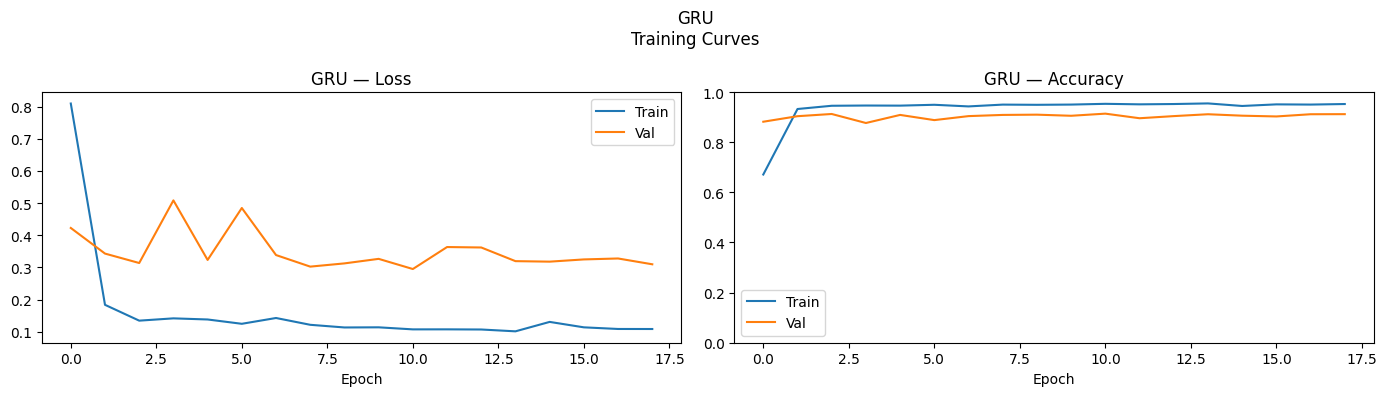

In [ ]:
fig, axes = plt.subplots(1, 2, figsize=(14, 4))

axes[0].plot(history_gru.history['loss'],     label='Train')
axes[0].plot(history_gru.history['val_loss'], label='Val')
axes[0].set_title('GRU — Loss')
axes[0].set_xlabel('Epoch')
axes[0].legend()

axes[1].plot(history_gru.history['accuracy'],     label='Train')
axes[1].plot(history_gru.history['val_accuracy'], label='Val')
axes[1].set_title('GRU — Accuracy')
axes[1].set_xlabel('Epoch')
axes[1].set_ylim(0, 1)
axes[1].legend()

plt.suptitle('GRU\nTraining Curves')
plt.tight_layout()
plt.show()

### GRU Evaluation

Accuracy      : 0.9141
F1 (weighted) : 0.9132

Per-class F1:
  WALKING             : 0.9689
  WALKING_UPSTAIRS    : 0.9654
  WALKING_DOWNSTAIRS  : 0.9282
  SITTING             : 0.7801
  STANDING            : 0.8441
  LAYING              : 0.9944

                    precision    recall  f1-score   support

           WALKING     0.9957    0.9435    0.9689       496
  WALKING_UPSTAIRS     0.9845    0.9469    0.9654       471
WALKING_DOWNSTAIRS     0.8660    1.0000    0.9282       420
           SITTING     0.8527    0.7189    0.7801       491
          STANDING     0.8065    0.8853    0.8441       532
            LAYING     0.9908    0.9981    0.9944       537

          accuracy                         0.9141      2947
         macro avg     0.9160    0.9155    0.9135      2947
      weighted avg     0.9166    0.9141    0.9132      2947



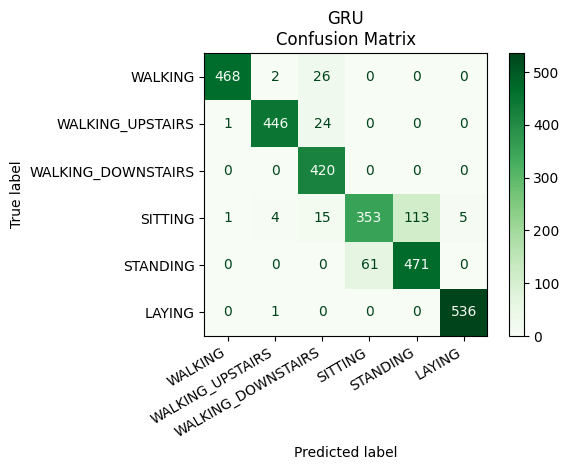

In [ ]:
gru_loss, gru_acc = model_gru.evaluate(X_test, y_test.flatten(), verbose=0)
y_pred_gru = np.argmax(model_gru.predict(X_test, verbose=0), axis=1)
y_true = y_test.flatten()

gru_f1_weighted = f1_score(y_true, y_pred_gru, average='weighted')
gru_f1_per_class = f1_score(y_true, y_pred_gru, average=None)

gru_best_val_acc = max(history_gru.history['val_accuracy'])

print(f"Accuracy      : {gru_acc:.4f}")
print(f"F1 (weighted) : {gru_f1_weighted:.4f}")
print("\nPer-class F1:")
for name, score in zip(activity_names, gru_f1_per_class):
    print(f"  {name:<20}: {score:.4f}")

print("\n" + classification_report(y_true, y_pred_gru, target_names=activity_names, digits=4))

ConfusionMatrixDisplay.from_predictions(
    y_true, y_pred_gru,
    display_labels=activity_names,
    cmap='Greens'
)
plt.title('GRU\nConfusion Matrix')
plt.xticks(rotation=30, ha='right')
plt.tight_layout()
plt.show()

## LTSM

### Build & Train LSTM

In [ ]:
X_train_lstm = X_train
X_test_lstm  = X_test

y_train_lstm = np.array(y_train).flatten()
y_test_lstm  = np.array(y_test).flatten()

# Build LSTM
model_lstm = Sequential([
    LSTM(128, return_sequences=True, input_shape=(128, 9)),
    Dropout(0.3),
    LSTM(64),
    Dropout(0.3),
    Dense(6, activation='softmax')
])

model_lstm.compile(optimizer='adam',
                   loss='sparse_categorical_crossentropy',
                   metrics=['accuracy'])

model_lstm.summary()

# Train
early_stop_lstm = EarlyStopping(monitor='val_loss', patience=7, restore_best_weights=True)

t0 = time.time()
history_lstm = model_lstm.fit(X_train_lstm, y_train_lstm,
                               epochs=50,
                               batch_size=64,
                               validation_data=(X_test_lstm, y_test_lstm),
                               callbacks=[early_stop_lstm])
lstm_time = time.time() - t0
print(f"\nLSTM training time: {lstm_time:.1f} seconds")

/usr/local/lib/python3.12/dist-packages/keras/src/layers/rnn/rnn.py:199: UserWarning: Do not pass an `input_shape`/`input_dim` argument to a layer. When using Sequential models, prefer using an `Input(shape)` object as the first layer in the model instead.
  super().__init__(**kwargs)


Model: "sequential_2"

┏━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━┓
┃ Layer (type)                    ┃ Output Shape           ┃       Param # ┃
┡━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━┩
│ lstm (LSTM)                     │ (None, 128, 128)       │        70,656 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dropout_4 (Dropout)             │ (None, 128, 128)       │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ lstm_1 (LSTM)                   │ (None, 64)             │        49,408 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dropout_5 (Dropout)             │ (None, 64)             │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dense_2 (Dense)                 │ (None, 6)              │           390 │
└─────────────────────────────────┴────────────────────────┴───────────────┘

 Total params: 120,454 (470.52 KB)

 Trainable params: 120,454 (470.52 KB)

 Non-trainable params: 0 (0.00 B)

Epoch 1/50
115/115 ━━━━━━━━━━━━━━━━━━━━ 10s 45ms/step - accuracy: 0.7685 - loss: 0.6183 - val_accuracy: 0.8147 - val_loss: 0.5680
Epoch 2/50
115/115 ━━━━━━━━━━━━━━━━━━━━ 3s 27ms/step - accuracy: 0.9241 - loss: 0.2305 - val_accuracy: 0.9080 - val_loss: 0.2681
Epoch 3/50
115/115 ━━━━━━━━━━━━━━━━━━━━ 3s 27ms/step - accuracy: 0.9427 - loss: 0.1437 - val_accuracy: 0.8999 - val_loss: 0.2828
Epoch 4/50
115/115 ━━━━━━━━━━━━━━━━━━━━ 6s 39ms/step - accuracy: 0.9465 - loss: 0.1325 - val_accuracy: 0.9053 - val_loss: 0.3108
Epoch 5/50
115/115 ━━━━━━━━━━━━━━━━━━━━ 3s 25ms/step - accuracy: 0.9518 - loss: 0.1224 - val_accuracy: 0.8924 - val_loss: 0.3560
Epoch 6/50
115/115 ━━━━━━━━━━━━━━━━━━━━ 3s 26ms/step - accuracy: 0.9499 - loss: 0.1266 - val_accuracy: 0.9162 - val_loss: 0.2610
Epoch 7/50
115/115 ━━━━━━━━━━━━━━━━━━━━ 3s 25ms/step - accuracy: 0.9517 - loss: 0.1156 - val_accuracy: 0.9169 - val_loss: 0.2608
Epoch 8/50
115/115 ━━━━━━━━━━━━━━━━━━━━ 4s 35ms/step - accuracy: 0.9509 - loss: 0.1135 - val_acc

### LSTM Training Curves

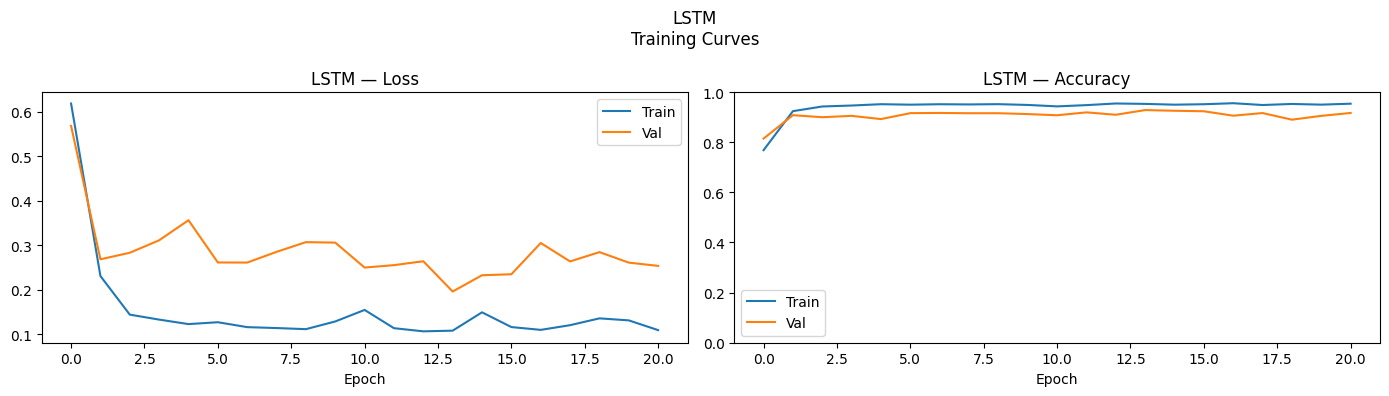

In [ ]:
fig, axes = plt.subplots(1, 2, figsize=(14, 4))

axes[0].plot(history_lstm.history['loss'],     label='Train')
axes[0].plot(history_lstm.history['val_loss'], label='Val')
axes[0].set_title('LSTM — Loss')
axes[0].set_xlabel('Epoch')
axes[0].legend()

axes[1].plot(history_lstm.history['accuracy'],     label='Train')
axes[1].plot(history_lstm.history['val_accuracy'], label='Val')
axes[1].set_title('LSTM — Accuracy')
axes[1].set_xlabel('Epoch')
axes[1].set_ylim(0, 1)
axes[1].legend()

plt.suptitle('LSTM\nTraining Curves')
plt.tight_layout()
plt.show()

### LSTM Evaluation

Accuracy      : 0.9284
F1 (weighted) : 0.9283

Per-class F1:
  WALKING             : 0.9868
  WALKING_UPSTAIRS    : 0.9725
  WALKING_DOWNSTAIRS  : 0.9941
  SITTING             : 0.8000
  STANDING            : 0.8315
  LAYING              : 0.9972

                    precision    recall  f1-score   support

           WALKING     0.9919    0.9819    0.9868       496
  WALKING_UPSTAIRS     0.9684    0.9766    0.9725       471
WALKING_DOWNSTAIRS     0.9929    0.9952    0.9941       420
           SITTING     0.8058    0.7943    0.8000       491
          STANDING     0.8284    0.8346    0.8315       532
            LAYING     0.9944    1.0000    0.9972       537

          accuracy                         0.9284      2947
         macro avg     0.9303    0.9304    0.9303      2947
      weighted avg     0.9282    0.9284    0.9283      2947



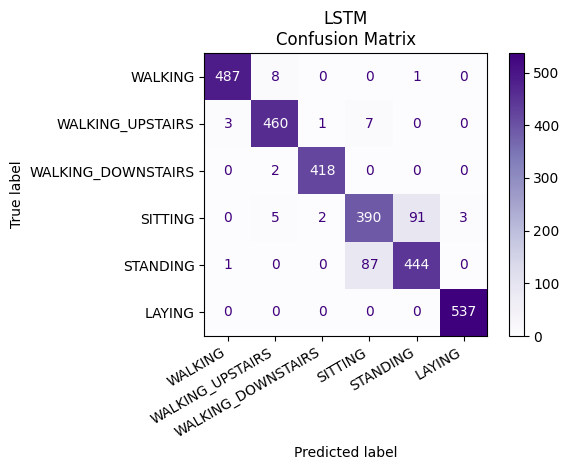

In [ ]:
lstm_loss, lstm_acc = model_lstm.evaluate(X_test, y_test.flatten(), verbose=0)
y_pred_lstm = np.argmax(model_lstm.predict(X_test, verbose=0), axis=1)
y_true = y_test.flatten()

lstm_f1_weighted = f1_score(y_true, y_pred_lstm, average='weighted')
lstm_f1_per_class = f1_score(y_true, y_pred_lstm, average=None)

lstm_best_val_acc = max(history_lstm.history['val_accuracy'])

print(f"Accuracy      : {lstm_acc:.4f}")
print(f"F1 (weighted) : {lstm_f1_weighted:.4f}")
print("\nPer-class F1:")
for name, score in zip(activity_names, lstm_f1_per_class):
    print(f"  {name:<20}: {score:.4f}")

print("\n" + classification_report(y_true, y_pred_lstm, target_names=activity_names, digits=4))

ConfusionMatrixDisplay.from_predictions(
    y_true, y_pred_lstm,
    display_labels=activity_names,
    cmap='Purples'
)
plt.title('LSTM\nConfusion Matrix')
plt.xticks(rotation=30, ha='right')
plt.tight_layout()
plt.show()

## Fine-tune PatchTST Time-Series Transformer

### Preprocessing

In [ ]:
# Load subject
subject_test = pd.read_csv(
    "/content/Dataset/test/subject_test.txt",
    header=None,
    names=['subject']
)

In [ ]:
np.unique(subject_test['subject'])

array([ 2,  4,  9, 10, 12, 13, 18, 20, 24])

In [ ]:
val_mask = np.isin(subject_test['subject'], [18, 20, 24])

X_val = X_test[val_mask]  #These are scaled
y_val = y_test[val_mask]

test_mask = ~np.isin(subject_test['subject'], [18, 20, 24])

X_test = X_test[test_mask]
y_test = y_test[test_mask]

In [ ]:
!pip install transformers evaluate accelerate datasets

In [ ]:
from datasets import Dataset

# Prepare Data
y_train = y_train.squeeze().astype(np.int64)
y_val = y_val.squeeze().astype(np.int64)
y_test = y_test.squeeze().astype(np.int64)

train_dataset = Dataset.from_dict({
    "past_values": X_train.astype(np.float32),
    "target_values": y_train.astype(np.int64)
})

val_dataset = Dataset.from_dict({
    "past_values": X_val.astype(np.float32),
    "target_values": y_val.astype(np.int64)
})

test_dataset = Dataset.from_dict({
    "past_values": X_test.astype(np.float32),
    "target_values": y_test.astype(np.int64)
})

### Fine-tuning

In [ ]:
from transformers import PatchTSTForClassification, PatchTSTConfig, TrainingArguments, Trainer
import evaluate
import os

# Fine-Tuning
# Prepare Model Configuration
config = PatchTSTConfig(
    num_input_channels=9,
    context_length=128,
    num_targets=6,
    patch_length=16,
    stride=8,
    n_heads=8,
    num_layers=4,
    dropout=0.1
)

# Load Pre-trained Transformer
model = PatchTSTForClassification.from_pretrained("ibm-granite/granite-timeseries-patchtst", config=config, ignore_mismatched_sizes=True)


# Define the compute_metrics function
accuracy_metric = evaluate.load("accuracy")
def compute_metrics(eval_pred):
    predictions, labels = eval_pred
    predictions = np.argmax(predictions, axis=1)
    results = accuracy_metric.compute(predictions=predictions, references=labels)
    return results

# Prepare Training Arguments
training_args = TrainingArguments(
    output_dir="./har_patchtst_results",
    num_train_epochs=20,
    per_device_train_batch_size=16,
    learning_rate=1e-3,
    weight_decay=0.01,
    eval_strategy="epoch",
    save_strategy="epoch",
    load_best_model_at_end=True,
    metric_for_best_model="accuracy",
    label_names=["target_values"],
    push_to_hub=False,
    remove_unused_columns=False,
)

trainer = Trainer(
    model=model,
    args=training_args,
    train_dataset=train_dataset,
    eval_dataset=val_dataset,
    compute_metrics=compute_metrics,
)


train_result_transformer = trainer.train()

Loading weights:   0%|          | 0/69 [00:00<?, ?it/s]

PatchTSTForClassification LOAD REPORT from: ibm-granite/granite-timeseries-patchtst
Key                                           | Status     |                                                                                        
----------------------------------------------+------------+----------------------------------------------------------------------------------------
model.encoder.positional_encoder.cls_token    | UNEXPECTED |                                                                                        
head.projection.bias                          | UNEXPECTED |                                                                                        
head.projection.weight                        | UNEXPECTED |                                                                                        
head.linear.weight                            | MISSING    |                                                                                        
head.linear.bias      

Epoch,Training Loss,Validation Loss,Accuracy
1,No log,0.472532,0.814377
2,0.560850,0.310931,0.885350
3,0.373357,0.389943,0.850773
4,0.330208,0.228830,0.909008
5,0.280658,0.415921,0.859873
6,0.259957,0.278083,0.904459
7,0.241488,0.327278,0.878981
8,0.215334,0.503739,0.848044
9,0.194444,0.307973,0.886260
10,0.187314,0.366232,0.887170


Writing model shards:   0%|          | 0/1 [00:00<?, ?it/s]

Writing model shards:   0%|          | 0/1 [00:00<?, ?it/s]

...

Writing model shards:   0%|          | 0/1 [00:00<?, ?it/s]

Writing model shards:   0%|          | 0/1 [00:00<?, ?it/s]

Writing model shards:   0%|          | 0/1 [00:00<?, ?it/s]

Writing model shards:   0%|          | 0/1 [00:00<?, ?it/s]

Writing model shards:   0%|          | 0/1 [00:00<?, ?it/s]

### Transformer Training Curves

In [ ]:
history_transformer = trainer.state.log_history

print(history_transformer)

eval_loss = [x['eval_loss'] for x in history_transformer if 'eval_loss' in x.keys()]
eval_accuracy = [x['eval_accuracy'] for x in history_transformer if 'eval_accuracy' in x.keys()]
loss = [x['loss'] for x in history_transformer if 'loss' in x.keys()]

[{'eval_loss': 0.4725320637226105, 'eval_accuracy': 0.8143767060964513, 'eval_runtime': 5.2434, 'eval_samples_per_second': 209.596, 'eval_steps_per_second': 26.319, 'epoch': 1.0, 'step': 460}, {'loss': 0.5608504638671875, 'grad_norm': 4.976228713989258, 'learning_rate': 0.0009457608695652175, 'epoch': 1.0869565217391304, 'step': 500}, {'eval_loss': 0.31093069911003113, 'eval_accuracy': 0.8853503184713376, 'eval_runtime': 2.079, 'eval_samples_per_second': 528.614, 'eval_steps_per_second': 66.377, 'epoch': 2.0, 'step': 920}, {'loss': 0.3733565673828125, 'grad_norm': 6.414887428283691, 'learning_rate': 0.0008914130434782609, 'epoch': 2.1739130434782608, 'step': 1000}, {'eval_loss': 0.38994312286376953, 'eval_accuracy': 0.8507734303912647, 'eval_runtime': 2.6142, 'eval_samples_per_second': 420.395, 'eval_steps_per_second': 52.788, 'epoch': 3.0, 'step': 1380}, {'loss': 0.33020834350585937, 'grad_norm': 4.715080738067627, 'learning_rate': 0.0008370652173913044, 'epoch': 3.260869565217391, 's

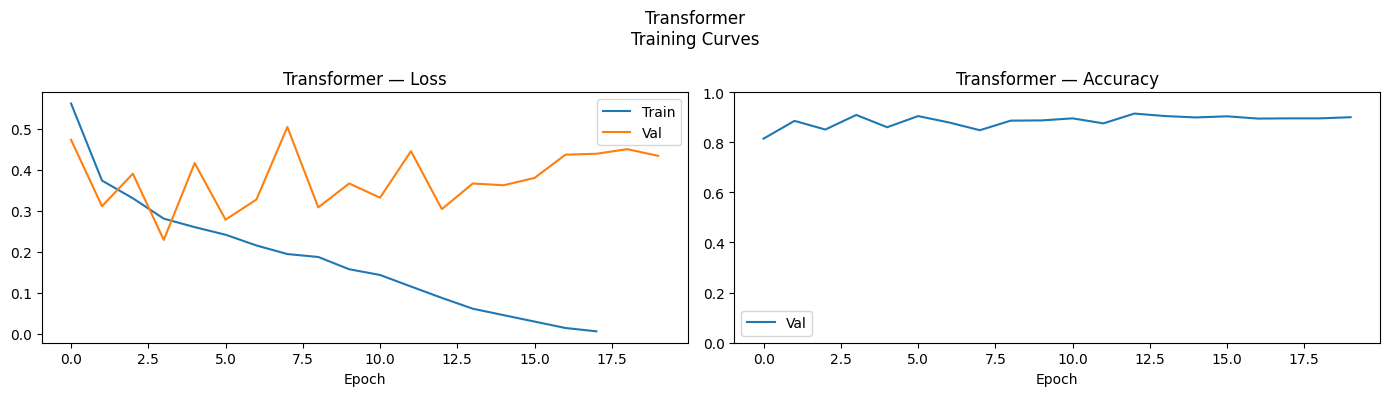

In [ ]:
fig, axes = plt.subplots(1, 2, figsize=(14, 4))

axes[0].plot(loss, label='Train')
axes[0].plot(eval_loss, label='Val')
axes[0].set_title('Transformer — Loss')
axes[0].set_xlabel('Epoch')
axes[0].legend()

axes[1].plot(eval_accuracy, label='Val')
axes[1].set_title('Transformer — Accuracy')
axes[1].set_xlabel('Epoch')
axes[1].set_ylim(0, 1)
axes[1].legend()

plt.suptitle('Transformer\nTraining Curves')
plt.tight_layout()
plt.show()

### Transformer Evaluation

In [ ]:
transformer_time = train_result_transformer.metrics['train_runtime']

Accuracy      : 0.8837
F1 (weighted) : 0.8850

Per-class F1:
  WALKING             : 0.9607
  WALKING_UPSTAIRS    : 0.9731
  WALKING_DOWNSTAIRS  : 0.9905
  SITTING             : 0.7595
  STANDING            : 0.7845
  LAYING              : 0.8541

                    precision    recall  f1-score   support

           WALKING     0.9607    0.9607    0.9607       331
  WALKING_UPSTAIRS     0.9931    0.9538    0.9731       303
WALKING_DOWNSTAIRS     0.9962    0.9849    0.9905       265
           SITTING     0.6953    0.8367    0.7595       300
          STANDING     0.8412    0.7350    0.7845       317
            LAYING     0.8620    0.8464    0.8541       332

          accuracy                         0.8837      1848
         macro avg     0.8914    0.8862    0.8871      1848
      weighted avg     0.8898    0.8837    0.8850      1848



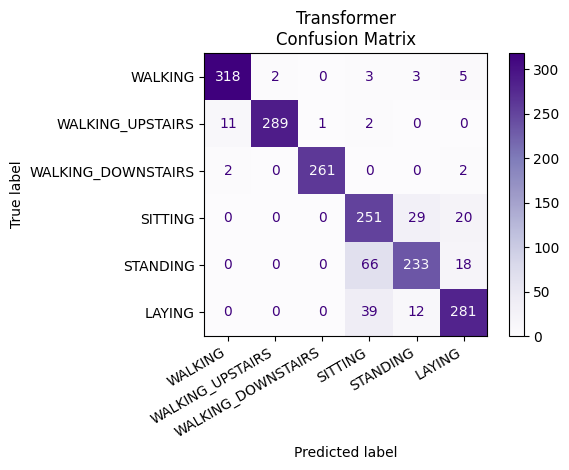

In [ ]:
metrics = trainer.evaluate(test_dataset)

prediction_output = trainer.predict(test_dataset)
preds_probs = prediction_output.predictions
y_pred_transformer = np.argmax(preds_probs, axis=1)

transformer_acc = accuracy_score(y_test, y_pred_transformer)
transformer_f1_weighted = f1_score(y_test, y_pred_transformer, average='weighted')
transformer_f1_per_class = f1_score(y_test, y_pred_transformer, average=None)
transformer_best_val_acc = metrics['eval_loss']

print(f"Accuracy      : {transformer_acc:.4f}")
print(f"F1 (weighted) : {transformer_f1_weighted:.4f}")
print("\nPer-class F1:")
for name, score in zip(activity_names, transformer_f1_per_class):
    print(f"  {name:<20}: {score:.4f}")

print("\n" + classification_report(y_test, y_pred_transformer, target_names=activity_names, digits=4))

ConfusionMatrixDisplay.from_predictions(
    y_test, y_pred_transformer,
    display_labels=activity_names,
    cmap='Purples'
)
plt.title('Transformer\nConfusion Matrix')
plt.xticks(rotation=30, ha='right')
plt.tight_layout()
plt.show()

## Final Comparison

---------------------------------------------------------------------------
RNN vs GRU vs LSTM vs Transformer — FINAL COMPARISON (Raw Sensor Sequences)
---------------------------------------------------------------------------
      Model Test Accuracy Best Val Accuracy Weighted F1 Training Time (s)
Vanilla RNN        0.8205            0.8463      0.8191              69.2
        GRU        0.9141            0.9141      0.9132              96.2
       LSTM        0.9284            0.9284      0.9283              87.9
Transformer        0.8837            0.4321      0.8850             631.4


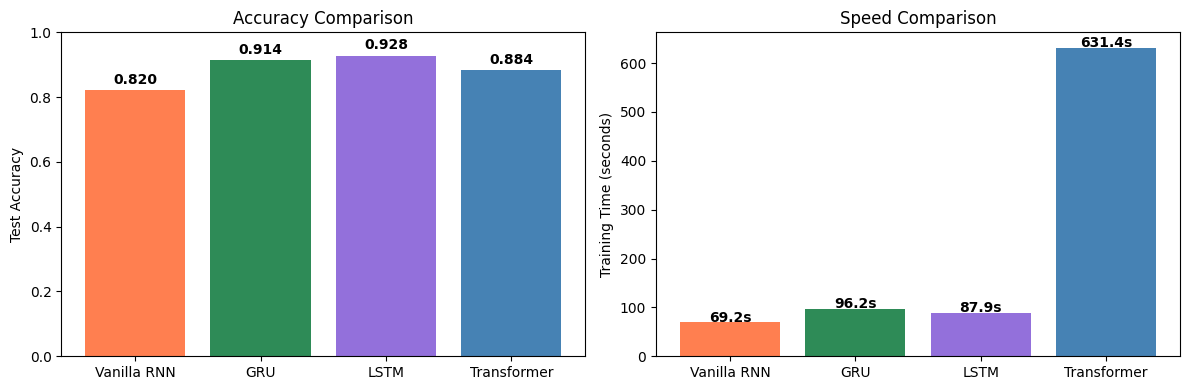

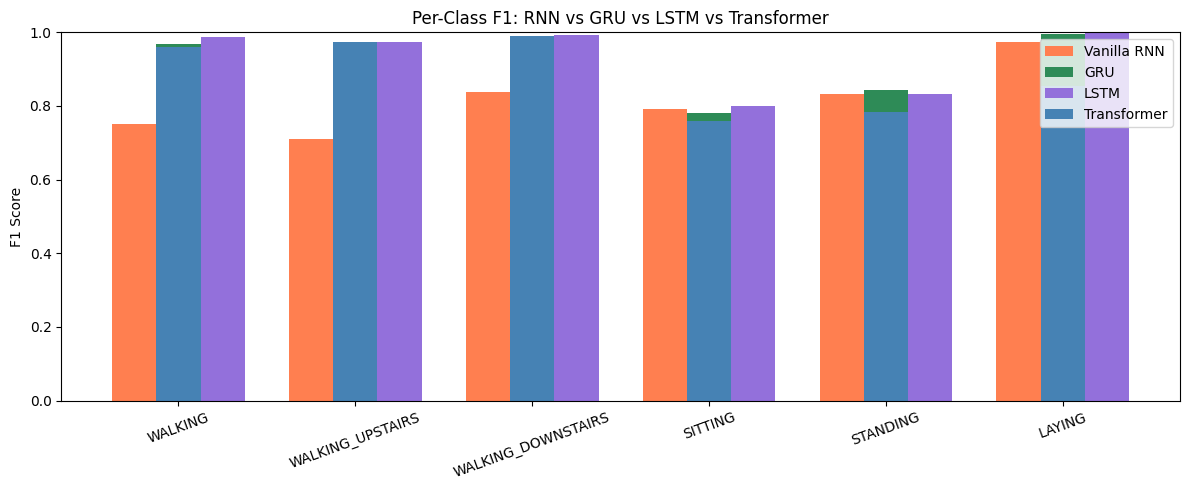

In [ ]:
summary = pd.DataFrame({
    'Model':             ['Vanilla RNN', 'GRU', 'LSTM', 'Transformer'],
    'Test Accuracy':     [f"{rnn_acc:.4f}", f"{gru_acc:.4f}", f"{lstm_acc:.4f}", f"{transformer_acc:.4f}"],
    'Best Val Accuracy': [f"{rnn_best_val_acc:.4f}", f"{gru_best_val_acc:.4f}", f"{lstm_best_val_acc:.4f}", f"{transformer_best_val_acc:.4f}"],
    'Weighted F1':       [f"{rnn_f1_weighted:.4f}", f"{gru_f1_weighted:.4f}", f"{lstm_f1_weighted:.4f}", f"{transformer_f1_weighted:.4f}"],
    'Training Time (s)': [f"{rnn_time:.1f}", f"{gru_time:.1f}", f"{lstm_time:.1f}", f"{transformer_time:.1f}"],
})

print("-" * 75)
print("RNN vs GRU vs LSTM vs Transformer — FINAL COMPARISON (Raw Sensor Sequences)")
print("-" * 75)
print(summary.to_string(index=False))

colors = ['coral', 'seagreen', 'mediumpurple', 'steelblue']
models = ['Vanilla RNN', 'GRU', 'LSTM', 'Transformer']

# Accuracy & Time side by side
fig, axes = plt.subplots(1, 2, figsize=(12, 4))

axes[0].bar(models, [rnn_acc, gru_acc, lstm_acc, transformer_acc], color=colors)
axes[0].set_ylabel('Test Accuracy')
axes[0].set_ylim(0, 1)
axes[0].set_title('Accuracy Comparison')
for i, v in enumerate([rnn_acc, gru_acc, lstm_acc, transformer_acc]):
    axes[0].text(i, v + 0.02, f"{v:.3f}", ha='center', fontweight='bold')

axes[1].bar(models, [rnn_time, gru_time, lstm_time, transformer_time], color=colors)
axes[1].set_ylabel('Training Time (seconds)')
axes[1].set_title('Speed Comparison')
for i, v in enumerate([rnn_time, gru_time, lstm_time, transformer_time]):
    axes[1].text(i, v + max(rnn_time, gru_time, lstm_time)*0.02,
                 f"{v:.1f}s", ha='center', fontweight='bold')

plt.tight_layout()
plt.show()

# Per-class F1 — all three models
x = np.arange(len(activity_names))
width = 0.25
plt.figure(figsize=(12, 5))
plt.bar(x - width,  rnn_f1_per_class,  width, label='Vanilla RNN', color='coral')
plt.bar(x,          gru_f1_per_class,  width, label='GRU',          color='seagreen')
plt.bar(x + width,  lstm_f1_per_class, width, label='LSTM',         color='mediumpurple')
plt.bar(x,          transformer_f1_per_class, width, label='Transformer', color='steelblue')
plt.xticks(x, activity_names, rotation=20)
plt.ylabel('F1 Score')
plt.title('Per-Class F1: RNN vs GRU vs LSTM vs Transformer')
plt.ylim(0, 1)
plt.legend()
plt.tight_layout()
plt.show()